<a href="https://colab.research.google.com/github/221FA04614/A-Hybrid-ConvNeXt-Swin-U-Net-for-Tumor-Aware-Brain-MRI-Segmentation-and-Classification/blob/main/139_completed_code_with_outputs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Complete Metrics & Validation — BRISC2025 Brain Tumor Project
**Segmentation + Classification (Stage 4 & Stage 5) + Comprehensive Evaluation**

This notebook runs the **entire pipeline end-to-end**:
1. **Segmentation** — Train Hybrid ConvNeXt–Swin UNet++ v4.0
2. **Feature Extraction** — Multi-backbone tumor-aware ROI features
3. **Classification Stage 4** — MLP, SVM, Ensemble (feature-based)
4. **Classification Stage 5** — Fine-tuned ConvNeXt, Swin, EfficientNet + TTA Ensemble
5. **Comprehensive Evaluation** — All metrics, confusion matrices, ROC curves

All artifacts saved to Google Drive: `BRICS_FEATURES_IN-drive/`

## 🔧 Step 1 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 🖥️ Step 2 — Environment Check

In [3]:
import torch, sys
print('=' * 60)
print('  ENVIRONMENT CHECK')
print('=' * 60)
print(f'  Python:    {sys.version.split()[0]}')
print(f'  PyTorch:   {torch.__version__}')
print(f'  CUDA:      {torch.version.cuda if torch.cuda.is_available() else "N/A"}')
if torch.cuda.is_available():
    print(f'  GPU:       {torch.cuda.get_device_name(0)}')
    print(f'  VRAM:      {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
else:
    print('  ⚠️  No GPU detected!')
print('=' * 60)

  ENVIRONMENT CHECK
  Python:    3.12.12
  PyTorch:   2.10.0+cu128
  CUDA:      12.8
  GPU:       Tesla T4
  VRAM:      14.6 GB


## 📦 Step 3 — Install Dependencies

In [4]:
!pip install -q timm albumentations seaborn scikit-learn xgboost lightgbm catboost joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.7 MB/s eta 0:00:00


## 📚 Step 4 — Imports

In [5]:
import os, gc, copy, json, zipfile, warnings
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from torch.cuda.amp import GradScaler, autocast
from torch.optim.swa_utils import AveragedModel, update_bn
from scipy.ndimage import binary_fill_holes
from skimage.morphology import remove_small_objects
from scipy.spatial.distance import directed_hausdorff
from scipy.spatial import cKDTree
import joblib
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, balanced_accuracy_score,
    cohen_kappa_score, matthews_corrcoef, roc_auc_score, roc_curve, auc
)
warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ All imports successful — Device: {device}')

✅ All imports successful — Device: cuda


## 📂 Step 5 — Extract Dataset
Edit `ZIP_PATH` if your dataset zip is in a different location.

In [6]:
ZIP_PATH = '/content/drive/MyDrive/brisc2025.zip'
EXTRACT_ROOT = '/content/brisc2025'

if not os.path.isdir(EXTRACT_ROOT):
    print(f'📦 Extracting {ZIP_PATH}...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('/content')
    print('✅ Extraction complete!')
else:
    print('✅ Dataset already extracted')

# Paths
TRAIN_IMG  = f'{EXTRACT_ROOT}/segmentation_task/train/images'
TRAIN_MASK = f'{EXTRACT_ROOT}/segmentation_task/train/masks'
VAL_IMG    = f'{EXTRACT_ROOT}/segmentation_task/test/images'
VAL_MASK   = f'{EXTRACT_ROOT}/segmentation_task/test/masks'

for name, path in [('Train Images', TRAIN_IMG), ('Train Masks', TRAIN_MASK),
                    ('Val Images', VAL_IMG), ('Val Masks', VAL_MASK)]:
    exists = os.path.isdir(path)
    count = len(os.listdir(path)) if exists else 0
    status = f'✅ {count} files' if exists else '❌ NOT FOUND'
    print(f'  {status}  {name}: {path}')

📦 Extracting /content/drive/MyDrive/brisc2025.zip...
✅ Extraction complete!
  ✅ 3933 files  Train Images: /content/brisc2025/segmentation_task/train/images
  ✅ 3933 files  Train Masks: /content/brisc2025/segmentation_task/train/masks
  ✅ 860 files  Val Images: /content/brisc2025/segmentation_task/test/images
  ✅ 860 files  Val Masks: /content/brisc2025/segmentation_task/test/masks


## ⚙️ Step 6 — Configuration
All hyperparameters and save directory.

In [7]:
# ── Master Save Directory (NEW folder in Drive) ──
MASTER_SAVE = '/content/drive/MyDrive/BRICS_FEATURES_IN-drive'
os.makedirs(MASTER_SAVE, exist_ok=True)

# Sub-directories
SEG_SAVE    = os.path.join(MASTER_SAVE, 'segmentation')
FEAT_SAVE   = os.path.join(MASTER_SAVE, 'features')
CLS4_SAVE   = os.path.join(MASTER_SAVE, 'stage4_classification')
CLS5_SAVE   = os.path.join(MASTER_SAVE, 'stage5_classification')
EVAL_SAVE   = os.path.join(MASTER_SAVE, 'evaluation')
for d in [SEG_SAVE, FEAT_SAVE, CLS4_SAVE, CLS5_SAVE, EVAL_SAVE]:
    os.makedirs(d, exist_ok=True)

# ── Segmentation Config ──
CONFIG = {
    'batch_size': 8, 'num_epochs': 60, 'max_lr': 2e-4,
    'weight_decay': 1e-2, 'early_stopping_patience': 5,
    'grad_clip': 1.0, 'use_amp': True,
    'image_size': 256, 'num_workers': 2, 'pin_memory': True,
    'dice_weight': 0.5, 'focal_weight': 0.3, 'boundary_weight': 0.2,
    'focal_gamma': 2.0, 'focal_alpha': 0.25,
    'ds_anneal_epoch': 30,
    'use_ema': True, 'ema_decay': 0.999,
    'use_tta': True, 'use_postprocessing': True, 'min_object_size': 50,
    'use_cross_attention_fusion': True, 'use_aspp': True,
    'use_cbam': True, 'use_boundary_loss': True,
    'save_dir': SEG_SAVE,
}

# ── Classification Setup ──
CLASS_NAMES = ['glioma', 'meningioma', 'pituitary', 'no_tumor']
CLASS_MAP = {name: i for i, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)
CLASSIFY_ROOT = '/content/brisc2025/classification_task'
CLASSIFY_TRAIN = f'{CLASSIFY_ROOT}/train'
CLASSIFY_TEST  = f'{CLASSIFY_ROOT}/test'

# ── Stage 3 Config ──
STAGE3_CONFIG = {
    'feature_backbone': 'convnext_small.fb_in22k_ft_in1k',
    'feature_dim': 768, 'roi_input_size': 224, 'seg_input_size': 256,
    'batch_size': 16, 'seg_threshold': 0.5, 'min_tumor_pixels': 50,
    'flush_every': 50, 'save_dir': FEAT_SAVE,
}

# ── Stage 5 Config ──
STAGE5_CONFIG = {
    'save_dir': CLS5_SAVE, 'img_size': 224, 'batch_size': 16,
    'num_workers': 2, 'label_smoothing': 0.1,
    'mixup_alpha': 0.3, 'cutmix_alpha': 1.0, 'mixup_prob': 0.5,
    'epochs': 50, 'lr_head': 3e-3, 'lr_backbone': 3e-5,
    'unfreeze_epoch': 5, 'patience': 12, 'weight_decay': 0.05,
}

print('✅ Configuration loaded')
print(f'   Master save: {MASTER_SAVE}')

✅ Configuration loaded
   Master save: /content/drive/MyDrive/BRICS_FEATURES_IN-drive


## 🏗️ Step 7 — Segmentation Model Architecture

In [8]:
# ── Sub-modules ──
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        mid = max(channels // reduction, 8)
        self.fc = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, mid), nn.ReLU(inplace=True),
            nn.Linear(mid, channels), nn.Sigmoid())
    def forward(self, x):
        return x * self.fc(x).unsqueeze(-1).unsqueeze(-1)
class CrossAttentionResidualFusion(nn.Module):
    def __init__(self, cnn_ch, trans_ch, out_ch, num_heads=1, window_size=8):
        super().__init__()
        self.out_ch, self.num_heads, self.window_size = out_ch, num_heads, window_size
        self.head_dim = out_ch // num_heads
        self.cnn_proj = nn.Conv2d(cnn_ch, out_ch, 1)
        self.trans_proj = nn.Conv2d(trans_ch, out_ch, 1)
        self.q_proj = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.k_proj = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.v_proj = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.out_proj = nn.Linear(out_ch, out_ch)
        self.norm_cnn = nn.LayerNorm(out_ch)
        self.norm_trans = nn.LayerNorm(out_ch)
        self.se = SEBlock(out_ch, reduction=16)
        self.residual_proj = nn.Conv2d(cnn_ch, out_ch, 1) if cnn_ch != out_ch else nn.Identity()
    def _window_partition(self, x, ws):
        B, C, H, W = x.shape
        x = x.view(B, C, H // ws, ws, W // ws, ws).permute(0, 2, 4, 3, 5, 1).contiguous()
        nW = (H // ws) * (W // ws)
        return x.view(B * nW, ws * ws, C), B, nW
    def _window_reverse(self, x, B, H, W, ws):
        nH, nW_dim = H // ws, W // ws
        x = x.view(B, nH, nW_dim, ws, ws, -1).permute(0, 5, 1, 3, 2, 4).contiguous()
        return x.view(B, -1, H, W)
    def forward(self, cnn_feat, trans_feat):
        if trans_feat.shape[2:] != cnn_feat.shape[2:]:
            trans_feat = F.interpolate(trans_feat, size=cnn_feat.shape[2:], mode='bilinear', align_corners=False)
        residual = self.residual_proj(cnn_feat)
        B, _, H, W = cnn_feat.shape
        ws = min(self.window_size, H, W)
        pad_h, pad_w = (ws - H % ws) % ws, (ws - W % ws) % ws
        if pad_h > 0 or pad_w > 0:
            cnn_feat = F.pad(cnn_feat, (0, pad_w, 0, pad_h))
            trans_feat = F.pad(trans_feat, (0, pad_w, 0, pad_h))
            residual = F.pad(residual, (0, pad_w, 0, pad_h))
        Hp, Wp = cnn_feat.shape[2], cnn_feat.shape[3]
        cnn_p, trans_p = self.cnn_proj(cnn_feat), self.trans_proj(trans_feat)
        cnn_win, B_orig, nW = self._window_partition(cnn_p, ws)
        trans_win, _, _ = self._window_partition(trans_p, ws)
        cnn_win, trans_win = self.norm_cnn(cnn_win), self.norm_trans(trans_win)
        BnW, N, C = cnn_win.shape
        cnn_win = cnn_win.view(BnW, N, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        trans_win = trans_win.view(BnW, N, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        Q, K, V = self.q_proj(cnn_win), self.k_proj(trans_win), self.v_proj(trans_win)
        attn = (Q @ K.transpose(-2, -1)) * (self.head_dim ** -0.5)
        out = attn.softmax(dim=-1) @ V
        out = out.permute(0, 2, 1, 3).contiguous().view(BnW, N, C)
        out = self.out_proj(out)
        fused = self._window_reverse(out, B_orig, Hp, Wp, ws)
        if pad_h > 0 or pad_w > 0:
            fused, residual = fused[:, :, :H, :W], residual[:, :, :H, :W]
        return self.se(fused) + residual
class SimpleFusion(nn.Module):
    def __init__(self, cnn_ch, trans_ch, out_ch):
        super().__init__()
        self.cnn_proj = nn.Conv2d(cnn_ch, out_ch, 1)
        self.trans_proj = nn.Conv2d(trans_ch, out_ch, 1)
        self.attn = nn.Sequential(nn.Conv2d(out_ch*2, out_ch, 1), nn.BatchNorm2d(out_ch), nn.GELU(),
                                  nn.Conv2d(out_ch, 2, 1), nn.Softmax(dim=1))
    def forward(self, cnn_feat, trans_feat):
        if trans_feat.shape[2:] != cnn_feat.shape[2:]:
            trans_feat = F.interpolate(trans_feat, size=cnn_feat.shape[2:], mode='bilinear', align_corners=False)
        cp, tp = self.cnn_proj(cnn_feat), self.trans_proj(trans_feat)
        w = self.attn(torch.cat([cp, tp], dim=1))
        return w[:, 0:1] * cp + w[:, 1:2] * tp
class LightweightASPP(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        mid = in_ch // 4
        self.conv1x1 = nn.Sequential(nn.Conv2d(in_ch, mid, 1, bias=False), nn.BatchNorm2d(mid), nn.GELU())
        self.conv_d6 = nn.Sequential(nn.Conv2d(in_ch, in_ch, 3, padding=6, dilation=6, groups=in_ch, bias=False),
            nn.Conv2d(in_ch, mid, 1, bias=False), nn.BatchNorm2d(mid), nn.GELU())
        self.conv_d12 = nn.Sequential(nn.Conv2d(in_ch, in_ch, 3, padding=12, dilation=12, groups=in_ch, bias=False),
            nn.Conv2d(in_ch, mid, 1, bias=False), nn.BatchNorm2d(mid), nn.GELU())
        self.pool = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(in_ch, mid, 1, bias=False), nn.BatchNorm2d(mid), nn.GELU())
        self.fuse = nn.Sequential(nn.Conv2d(mid*4, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch), nn.GELU())
    def forward(self, x):
        sz = x.shape[2:]
        return self.fuse(torch.cat([self.conv1x1(x), self.conv_d6(x), self.conv_d12(x),
            F.interpolate(self.pool(x), size=sz, mode='bilinear', align_corners=False)], dim=1))
class CBAMLite(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        mid = max(channels // reduction, 8)
        self.channel_attn = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, mid), nn.ReLU(inplace=True), nn.Linear(mid, channels), nn.Sigmoid())
        self.spatial_attn = nn.Sequential(nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm2d(1), nn.Sigmoid())
    def forward(self, x):
        x = x * self.channel_attn(x).unsqueeze(-1).unsqueeze(-1)
        avg_out = x.mean(dim=1, keepdim=True)
        max_out = x.max(dim=1, keepdim=True)[0]
        return x * self.spatial_attn(torch.cat([avg_out, max_out], dim=1))
class AttentionGate(nn.Module):
    def __init__(self, gate_ch, skip_ch, inter_ch):
        super().__init__()
        self.W_g = nn.Conv2d(gate_ch, inter_ch, 1, bias=False)
        self.W_x = nn.Conv2d(skip_ch, inter_ch, 1, bias=False)
        self.psi = nn.Sequential(nn.Conv2d(inter_ch, 1, 1, bias=False), nn.BatchNorm2d(1), nn.Sigmoid())
        self.act = nn.GELU()
    def forward(self, gate, skip):
        g = F.interpolate(self.W_g(gate), size=skip.shape[2:], mode='bilinear', align_corners=False)
        return skip * self.psi(self.act(g + self.W_x(skip)))
class ResidualConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.conv = nn.Sequential(nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch),
            nn.GELU(), nn.Dropout2d(dropout), nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch))
        self.act = nn.GELU()
    def forward(self, x):
        return self.act(self.conv(x) + self.proj(x))
class ConvNeXtEncoder(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model('convnext_small', pretrained=pretrained, features_only=True)
        self.channels = self.backbone.feature_info.channels()
    def forward(self, x):
        return self.backbone(x)
class SwinEncoder(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model('swin_tiny_patch4_window7_224', pretrained=pretrained,
                                           img_size=256, features_only=True)
        self.channels = self.backbone.feature_info.channels()
    def forward(self, x):
        feats = self.backbone(x)
        return [f.permute(0, 3, 1, 2).contiguous() if f.dim() == 4 and f.shape[1] != self.channels[i]
                else f for i, f in enumerate(feats)]
print('✅ All sub-modules defined')

✅ All sub-modules defined


## 🏗️ Step 7b — Main Segmentation Model

In [9]:
class EnhancedHybridUNetPP_v4(nn.Module):
    def __init__(self, deep_supervision=True, dropout=0.1, config=None):
        super().__init__()
        if config is None: config = CONFIG
        self.deep_supervision = deep_supervision
        self.config = config
        self.convnext = ConvNeXtEncoder(pretrained=True)
        self.swin = SwinEncoder(pretrained=True)
        enc_ch = [96, 192, 384, 768]
        if config.get('use_cross_attention_fusion', True):
            self.fuse0 = CrossAttentionResidualFusion(enc_ch[0], enc_ch[0], enc_ch[0], num_heads=1, window_size=8)
            self.fuse1 = CrossAttentionResidualFusion(enc_ch[1], enc_ch[1], enc_ch[1], num_heads=1, window_size=8)
            self.fuse2 = CrossAttentionResidualFusion(enc_ch[2], enc_ch[2], enc_ch[2], num_heads=2, window_size=8)
            self.fuse3 = CrossAttentionResidualFusion(enc_ch[3], enc_ch[3], enc_ch[3], num_heads=2, window_size=8)
        else:
            self.fuse0 = SimpleFusion(enc_ch[0], enc_ch[0], enc_ch[0])
            self.fuse1 = SimpleFusion(enc_ch[1], enc_ch[1], enc_ch[1])
            self.fuse2 = SimpleFusion(enc_ch[2], enc_ch[2], enc_ch[2])
            self.fuse3 = SimpleFusion(enc_ch[3], enc_ch[3], enc_ch[3])
        if config.get('use_aspp', True):
            self.bottleneck = nn.Sequential(ResidualConvBlock(enc_ch[3], enc_ch[3], dropout), LightweightASPP(enc_ch[3], enc_ch[3]))
        else:
            self.bottleneck = ResidualConvBlock(enc_ch[3], enc_ch[3], dropout)
        dec_ch = [64, 128, 256, 512]
        use_cbam = config.get('use_cbam', True)
        if use_cbam:
            self.cbam0, self.cbam1, self.cbam2, self.cbam3 = CBAMLite(dec_ch[0]), CBAMLite(dec_ch[1]), CBAMLite(dec_ch[2]), CBAMLite(dec_ch[3])
        self.use_cbam = use_cbam
        self.conv3_1 = ResidualConvBlock(enc_ch[3]+enc_ch[3], dec_ch[3], dropout)
        self.conv2_1 = ResidualConvBlock(enc_ch[2]+dec_ch[3], dec_ch[2], dropout)
        self.conv1_1 = ResidualConvBlock(enc_ch[1]+dec_ch[2], dec_ch[1], dropout)
        self.conv0_1 = ResidualConvBlock(enc_ch[0]+dec_ch[1], dec_ch[0], dropout)
        self.conv2_2 = ResidualConvBlock(enc_ch[2]+dec_ch[2]+dec_ch[3], dec_ch[2], dropout)
        self.conv1_2 = ResidualConvBlock(enc_ch[1]+dec_ch[1]+dec_ch[2], dec_ch[1], dropout)
        self.conv0_2 = ResidualConvBlock(enc_ch[0]+dec_ch[0]+dec_ch[1], dec_ch[0], dropout)
        self.conv1_3 = ResidualConvBlock(enc_ch[1]+dec_ch[1]*2+dec_ch[2], dec_ch[1], dropout)
        self.conv0_3 = ResidualConvBlock(enc_ch[0]+dec_ch[0]*2+dec_ch[1], dec_ch[0], dropout)
        self.conv0_4 = ResidualConvBlock(enc_ch[0]+dec_ch[0]*3+dec_ch[1], dec_ch[0], dropout)
        self.ag3 = AttentionGate(enc_ch[3], enc_ch[3], enc_ch[3]//2)
        self.ag2 = AttentionGate(dec_ch[3], enc_ch[2], enc_ch[2]//2)
        self.ag1 = AttentionGate(dec_ch[2], enc_ch[1], enc_ch[1]//2)
        self.ag0 = AttentionGate(dec_ch[1], enc_ch[0], enc_ch[0]//2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        if deep_supervision:
            self.final1, self.final2, self.final3, self.final4 = nn.Conv2d(dec_ch[0],1,1), nn.Conv2d(dec_ch[0],1,1), nn.Conv2d(dec_ch[0],1,1), nn.Conv2d(dec_ch[0],1,1)
        else:
            self.final = nn.Conv2d(dec_ch[0], 1, 1)
        self.final_up = nn.Upsample(scale_factor=4, mode='bilinear', align_corners=False)

    def forward(self, x):
        c_feats, s_feats = self.convnext(x), self.swin(x)
        x0_0 = self.fuse0(c_feats[0], s_feats[0])
        x1_0 = self.fuse1(c_feats[1], s_feats[1])
        x2_0 = self.fuse2(c_feats[2], s_feats[2])
        x3_0 = self.fuse3(c_feats[3], s_feats[3])
        x4_0 = self.bottleneck(x3_0)
        x3_1 = self.conv3_1(torch.cat([self.ag3(x4_0, x3_0), x4_0], dim=1))
        if self.use_cbam: x3_1 = self.cbam3(x3_1)
        x2_1 = self.conv2_1(torch.cat([self.ag2(x3_1, x2_0), self.up(x3_1)], dim=1))
        if self.use_cbam: x2_1 = self.cbam2(x2_1)
        x1_1 = self.conv1_1(torch.cat([self.ag1(x2_1, x1_0), self.up(x2_1)], dim=1))
        if self.use_cbam: x1_1 = self.cbam1(x1_1)
        x0_1 = self.conv0_1(torch.cat([self.ag0(x1_1, x0_0), self.up(x1_1)], dim=1))
        if self.use_cbam: x0_1 = self.cbam0(x0_1)
        x2_2 = self.conv2_2(torch.cat([x2_0, x2_1, self.up(x3_1)], dim=1))
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, self.up(x2_2)], dim=1))
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, self.up(x1_2)], dim=1))
        x1_3 = self.conv1_3(torch.cat([x1_0, x1_1, x1_2, self.up(x2_2)], dim=1))
        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, self.up(x1_3)], dim=1))
        x0_4 = self.conv0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up(x1_3)], dim=1))
        if self.deep_supervision and self.training:
            return tuple(self.final_up(f(x0_4 if i==0 else [x0_4,x0_3,x0_2,x0_1][i])) for i, f in enumerate([self.final4, self.final3, self.final2, self.final1]))
        elif self.deep_supervision:
            return self.final_up(self.final4(x0_4))
        else:
            return self.final_up(self.final(x0_4))

print('✅ EnhancedHybridUNetPP_v4 defined')

✅ EnhancedHybridUNetPP_v4 defined


## 📊 Step 8 — Datasets, Loss & Training Utilities

In [10]:
def get_train_transforms(size=256):
    return A.Compose([
        A.Resize(size, size), A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=20, p=0.5),
        A.ElasticTransform(alpha=80, sigma=9, p=0.3),
        A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.3),
        A.CLAHE(clip_limit=2.0, p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
        A.GaussNoise(var_limit=(5.0, 30.0), p=0.2),
        A.CoarseDropout(max_holes=4, max_height=16, max_width=16, p=0.2),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)), ToTensorV2()])

def get_val_transforms(size=256):
    return A.Compose([A.Resize(size, size),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)), ToTensorV2()])

class SegmentationDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir, self.mask_dir, self.transform = Path(img_dir), Path(mask_dir), transform
        self.images = sorted(list(self.img_dir.glob('*.png')) + list(self.img_dir.glob('*.jpg')) + list(self.img_dir.glob('*.jpeg')))
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img_path = self.images[idx]
        mask_path = self.mask_dir / (img_path.stem + '.png')
        if not mask_path.exists(): mask_path = self.mask_dir / img_path.name
        if not mask_path.exists(): mask_path = self.mask_dir / (img_path.stem + '.jpg')
        image = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None: mask = np.zeros(image.shape[:2], dtype=np.uint8)
        mask = (mask > 127).astype(np.float32)
        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image, mask = aug['image'], aug['mask'].unsqueeze(0)
        return image, mask

class ClassificationFolderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform, self.samples = transform, []
        root = Path(root_dir)
        for cn in CLASS_NAMES:
            cd = root / cn
            if not cd.is_dir(): continue
            for p in sorted(list(cd.glob('*.jpg')) + list(cd.glob('*.png')) + list(cd.glob('*.jpeg'))):
                self.samples.append((str(p), CLASS_MAP[cn]))
        print(f'  Loaded {len(self.samples)} images from {root_dir}')
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        if self.transform: image = self.transform(image=image)['image']
        return image, label

class ClassificationDatasetWithPath(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform, self.samples = transform, []
        root = Path(root_dir)
        for cn in CLASS_NAMES:
            cd = root / cn
            if not cd.is_dir(): continue
            for p in sorted(list(cd.glob('*.jpg')) + list(cd.glob('*.png')) + list(cd.glob('*.jpeg'))):
                self.samples.append((str(p), CLASS_MAP[cn]))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        if self.transform: image = self.transform(image=image)['image']
        return image, label, img_path

print('✅ Datasets defined')

✅ Datasets defined


In [11]:
class CompoundSegLoss(nn.Module):
    def __init__(self, dice_w=0.5, focal_w=0.3, boundary_w=0.2, gamma=2.0, alpha=0.25):
        super().__init__()
        self.dice_w, self.focal_w, self.boundary_w = dice_w, focal_w, boundary_w
        self.gamma, self.alpha = gamma, alpha
        kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32).view(1,1,3,3)
        ky = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32).view(1,1,3,3)
        self.register_buffer('sobel_x', kx); self.register_buffer('sobel_y', ky)
    def dice_loss(self, pred, target):
        ps = torch.sigmoid(pred)
        inter = (ps * target).sum(dim=(2,3)); union = ps.sum(dim=(2,3)) + target.sum(dim=(2,3))
        return 1 - ((2*inter+1e-6)/(union+1e-6)).mean()
    def focal_loss(self, pred, target):
        bce = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
        pt = torch.exp(-bce); at = self.alpha*target + (1-self.alpha)*(1-target)
        return (at*(1-pt)**self.gamma*bce).mean()
    def boundary_loss(self, pred, target):
        with torch.amp.autocast('cuda', enabled=False):
            pf, tf = torch.sigmoid(pred.float()).clamp(1e-7,1-1e-7), target.float()
            ex, ey = F.conv2d(tf, self.sobel_x, padding=1), F.conv2d(tf, self.sobel_y, padding=1)
            em = (torch.sqrt(ex**2+ey**2+1e-6)>0.1).float()
            return F.binary_cross_entropy(pf, tf, weight=em*4.0+1.0, reduction='mean')
    def forward(self, pred, target, use_boundary=True):
        loss = self.dice_w*self.dice_loss(pred,target) + self.focal_w*self.focal_loss(pred,target)
        if use_boundary and self.boundary_w > 0: loss += self.boundary_w*self.boundary_loss(pred,target)
        return loss

def get_ds_weights(epoch, anneal_epoch=30):
    if epoch >= anneal_epoch: return [1.0, 0.0, 0.0, 0.0]
    t = epoch/anneal_epoch
    w = [0.4+0.6*t, 0.3*(1-t), 0.2*(1-t), 0.1*(1-t)]
    s = sum(w); return [x/s for x in w]

class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.decay, self.shadow, self.backup = decay, {}, {}
        for n,p in model.named_parameters():
            if p.requires_grad: self.shadow[n] = p.data.clone()
    @torch.no_grad()
    def update(self, model):
        for n,p in model.named_parameters():
            if p.requires_grad: self.shadow[n].mul_(self.decay).add_(p.data, alpha=1-self.decay)
    def apply_shadow(self, model):
        for n,p in model.named_parameters():
            if p.requires_grad: self.backup[n] = p.data.clone(); p.data.copy_(self.shadow[n])
    def restore(self, model):
        for n,p in model.named_parameters():
            if p.requires_grad: p.data.copy_(self.backup[n])
        self.backup = {}

def dice_coefficient(pred, target, smooth=1e-6):
    pf, tf = pred.contiguous().view(-1), target.contiguous().view(-1)
    return (2*(pf*tf).sum()+smooth)/(pf.sum()+tf.sum()+smooth)

def iou_score(pred, target, smooth=1e-6):
    pf, tf = pred.contiguous().view(-1), target.contiguous().view(-1)
    inter = (pf*tf).sum()
    return (inter+smooth)/(pf.sum()+tf.sum()-inter+smooth)

print('✅ Loss, EMA, metrics defined')

✅ Loss, EMA, metrics defined


## 🏋️ Step 9 — Segmentation Training

In [12]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device, scaler, ema, epoch, config):
    model.train()
    total_loss, n = 0.0, 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=config['use_amp']):
            outputs = model(images)
            if isinstance(outputs, tuple):
                ws = get_ds_weights(epoch, config['ds_anneal_epoch'])
                loss = sum(w*criterion(o, masks) for w, o in zip(ws, outputs))
            else:
                loss = criterion(outputs, masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model.parameters(), config['grad_clip'])
        scaler.step(optimizer); scaler.update(); scheduler.step()
        if ema: ema.update(model)
        total_loss += loss.item()*images.size(0); n += images.size(0)
    return total_loss/n

@torch.no_grad()
def validate(model, loader, device, threshold=0.5, use_tta=False, use_postproc=True, min_obj_size=50):
    model.eval()
    dices, ious = [], []
    for images, masks in loader:
        images, masks = images.to(device), masks
        with torch.amp.autocast('cuda'):
            logits = model(images)
            if isinstance(logits, tuple): logits = logits[0]
        preds = (torch.sigmoid(logits).cpu() > threshold).float()
        for i in range(preds.size(0)):
            d = dice_coefficient(preds[i], masks[i]).item()
            io = iou_score(preds[i], masks[i]).item()
            dices.append(d); ious.append(io)
    return np.mean(dices), np.std(dices), np.mean(ious)

def plot_training_history(history):
    fig, (a1,a2) = plt.subplots(1,2,figsize=(14,5))
    a1.plot(history['train_loss']); a1.set_title('Loss'); a1.grid(True,alpha=0.3)
    a2.plot(history['val_dice']); a2.set_title('Val Dice'); a2.grid(True,alpha=0.3)
    plt.tight_layout(); plt.show()

print('✅ Training functions defined')

✅ Training functions defined


  Hybrid ConvNeXt-Swin-UNet++ v4.0 — Training
  Train: 3933  |  Val: 860


model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  Params: 113.1M

Epoch 1/60
----------------------------------------------------------------------
  Loss: 0.3314  |  Dice: 0.0367 ± 0.0352  |  IoU: 0.0191  |  LR: 2.1e-05
  🎉 New best: 0.0367 — saved!

Epoch 2/60
----------------------------------------------------------------------
  Loss: 0.1703  |  Dice: 0.2732 ± 0.1731  |  IoU: 0.1708  |  LR: 5.6e-05
  🎉 New best: 0.2732 — saved!

Epoch 3/60
----------------------------------------------------------------------
  Loss: 0.1466  |  Dice: 0.7623 ± 0.1802  |  IoU: 0.6439  |  LR: 1.0e-04
  🎉 New best: 0.7623 — saved!

Epoch 4/60
----------------------------------------------------------------------
  Loss: 0.1428  |  Dice: 0.8369 ± 0.1770  |  IoU: 0.7492  |  LR: 1.5e-04
  🎉 New best: 0.8369 — saved!

Epoch 5/60
----------------------------------------------------------------------
  Loss: 0.1425  |  Dice: 0.8381 ± 0.1818  |  IoU: 0.7523  |  LR: 1.9e-04
  🎉 New best: 0.8381 — saved!

Epoch 6/60
-----------------------------------------

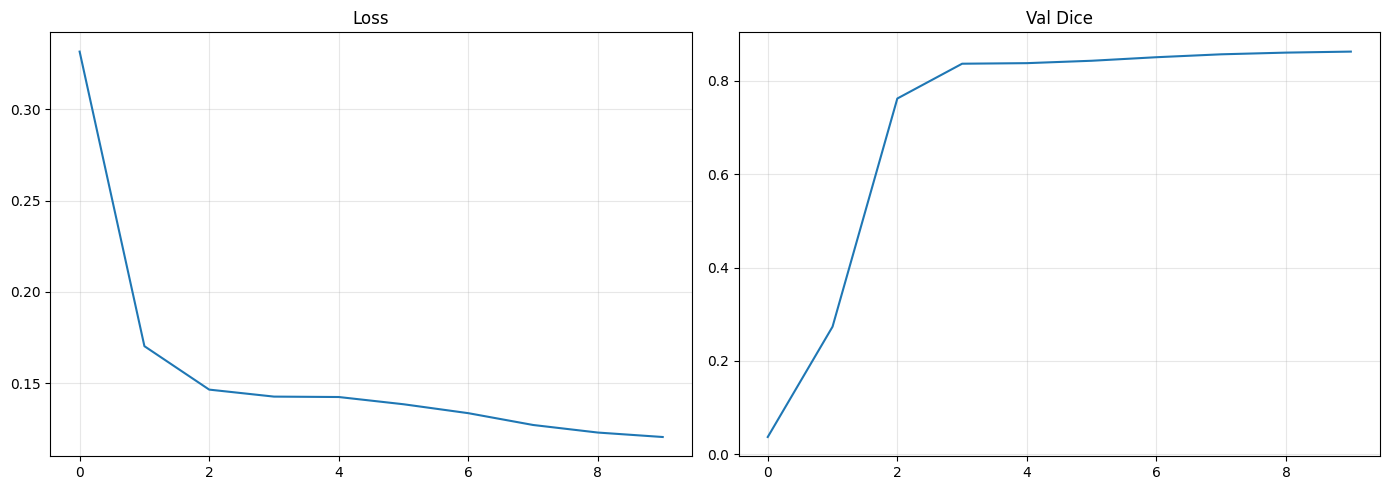


Epoch 11/60
----------------------------------------------------------------------
  Loss: 0.1193  |  Dice: 0.8626 ± 0.1762  |  IoU: 0.7887  |  LR: 2.0e-04
  No improvement (1/5)

Epoch 12/60
----------------------------------------------------------------------
  Loss: 0.1163  |  Dice: 0.8620 ± 0.1794  |  IoU: 0.7887  |  LR: 1.9e-04
  No improvement (2/5)

Epoch 13/60
----------------------------------------------------------------------
  Loss: 0.1138  |  Dice: 0.8636 ± 0.1775  |  IoU: 0.7909  |  LR: 1.9e-04
  🎉 New best: 0.8636 — saved!

Epoch 14/60
----------------------------------------------------------------------
  Loss: 0.1127  |  Dice: 0.8657 ± 0.1739  |  IoU: 0.7931  |  LR: 1.9e-04
  🎉 New best: 0.8657 — saved!

Epoch 15/60
----------------------------------------------------------------------
  Loss: 0.1109  |  Dice: 0.8662 ± 0.1741  |  IoU: 0.7939  |  LR: 1.9e-04
  🎉 New best: 0.8662 — saved!

Epoch 16/60
------------------------------------------------------------------

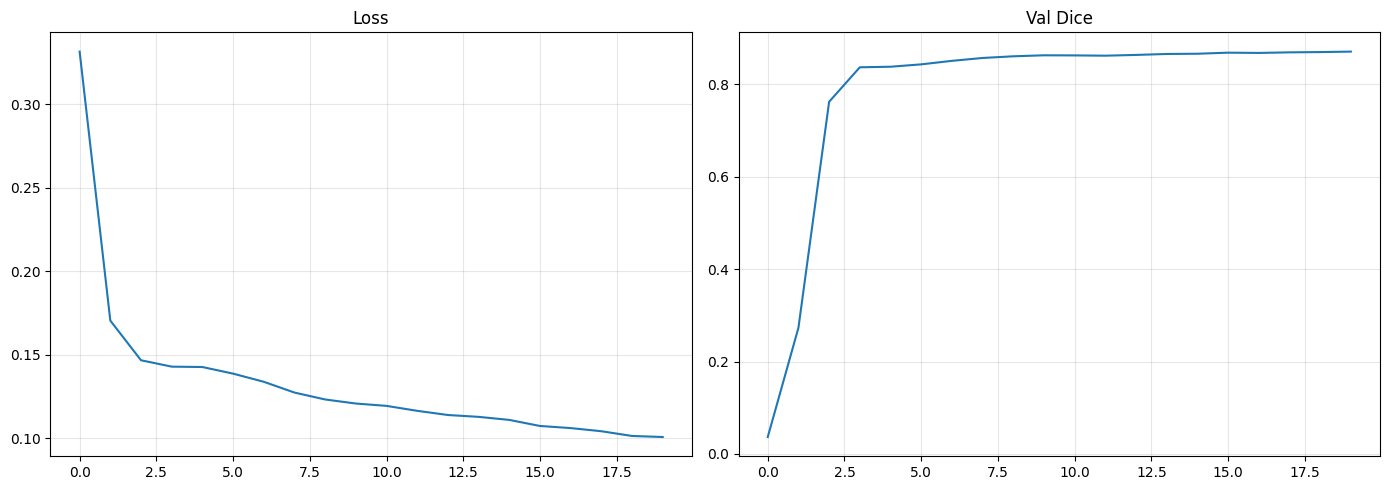


Epoch 21/60
----------------------------------------------------------------------
  Loss: 0.1005  |  Dice: 0.8713 ± 0.1672  |  IoU: 0.8001  |  LR: 1.6e-04
  🎉 New best: 0.8713 — saved!

Epoch 22/60
----------------------------------------------------------------------
  Loss: 0.0986  |  Dice: 0.8719 ± 0.1669  |  IoU: 0.8009  |  LR: 1.6e-04
  🎉 New best: 0.8719 — saved!

Epoch 23/60
----------------------------------------------------------------------
  Loss: 0.0947  |  Dice: 0.8723 ± 0.1670  |  IoU: 0.8014  |  LR: 1.5e-04
  🎉 New best: 0.8723 — saved!

Epoch 24/60
----------------------------------------------------------------------
  Loss: 0.0974  |  Dice: 0.8728 ± 0.1690  |  IoU: 0.8028  |  LR: 1.5e-04
  🎉 New best: 0.8728 — saved!

Epoch 25/60
----------------------------------------------------------------------
  Loss: 0.0959  |  Dice: 0.8740 ± 0.1686  |  IoU: 0.8045  |  LR: 1.4e-04
  🎉 New best: 0.8740 — saved!

Epoch 26/60
----------------------------------------------------

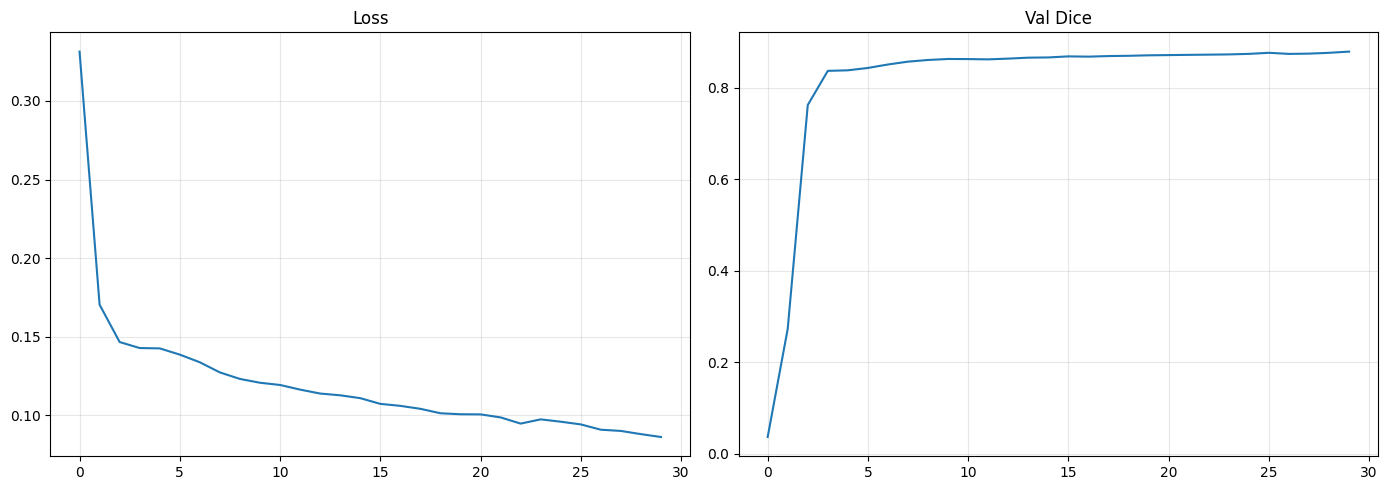


Epoch 31/60
----------------------------------------------------------------------
  Loss: 0.0875  |  Dice: 0.8796 ± 0.1603  |  IoU: 0.8111  |  LR: 1.1e-04
  🎉 New best: 0.8796 — saved!

Epoch 32/60
----------------------------------------------------------------------
  Loss: 0.0850  |  Dice: 0.8777 ± 0.1687  |  IoU: 0.8102  |  LR: 1.1e-04
  No improvement (1/5)

Epoch 33/60
----------------------------------------------------------------------
  Loss: 0.0823  |  Dice: 0.8790 ± 0.1673  |  IoU: 0.8119  |  LR: 1.0e-04
  No improvement (2/5)

Epoch 34/60
----------------------------------------------------------------------
  Loss: 0.0807  |  Dice: 0.8801 ± 0.1654  |  IoU: 0.8130  |  LR: 9.4e-05
  🎉 New best: 0.8801 — saved!

Epoch 35/60
----------------------------------------------------------------------
  Loss: 0.0814  |  Dice: 0.8789 ± 0.1722  |  IoU: 0.8129  |  LR: 8.8e-05
  No improvement (1/5)

Epoch 36/60
----------------------------------------------------------------------
  

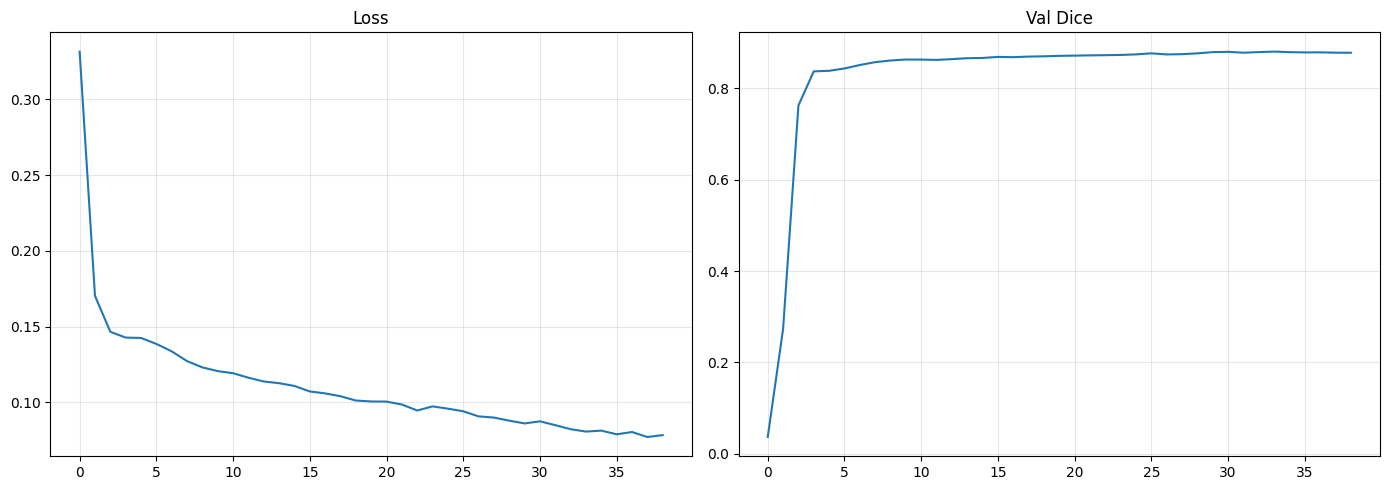

💾 Saved to /content/drive/MyDrive/BRICS_FEATURES_IN-drive/segmentation


In [13]:
save_dir = Path(CONFIG['save_dir']); save_dir.mkdir(parents=True, exist_ok=True)
print('='*70); print('  Hybrid ConvNeXt-Swin-UNet++ v4.0 — Training'); print('='*70)
with open(save_dir/'config.json','w') as f: json.dump(CONFIG, f, indent=2)
train_ds = SegmentationDataset(TRAIN_IMG, TRAIN_MASK, transform=get_train_transforms(CONFIG['image_size']))
val_ds = SegmentationDataset(VAL_IMG, VAL_MASK, transform=get_val_transforms(CONFIG['image_size']))
train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=CONFIG['num_workers'], pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'], pin_memory=True)
print(f'  Train: {len(train_ds)}  |  Val: {len(val_ds)}')
model = EnhancedHybridUNetPP_v4(deep_supervision=True, config=CONFIG).to(device)
print(f'  Params: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.1f}M')
criterion = CompoundSegLoss(dice_w=CONFIG['dice_weight'], focal_w=CONFIG['focal_weight'],
    boundary_w=CONFIG['boundary_weight'] if CONFIG['use_boundary_loss'] else 0.0,
    gamma=CONFIG['focal_gamma'], alpha=CONFIG['focal_alpha']).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['max_lr'], weight_decay=CONFIG['weight_decay'])
scheduler = OneCycleLR(optimizer, max_lr=CONFIG['max_lr'], total_steps=len(train_loader)*CONFIG['num_epochs'],
    pct_start=0.1, anneal_strategy='cos', div_factor=25, final_div_factor=1000)
scaler = GradScaler(enabled=CONFIG['use_amp'])
ema = ModelEMA(model, decay=CONFIG['ema_decay']) if CONFIG['use_ema'] else None
best_dice, patience_counter = 0.0, 0
history = {'train_loss': [], 'val_dice': [], 'lr': []}
for epoch in range(CONFIG['num_epochs']):
    print(f'\nEpoch {epoch+1}/{CONFIG["num_epochs"]}'); print('-'*70)
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, criterion, device, scaler, ema, epoch, CONFIG)
    if ema: ema.apply_shadow(model)
    val_dice, val_std, val_iou = validate(model, val_loader, device)
    if ema: ema.restore(model)
    lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_loss); history['val_dice'].append(val_dice); history['lr'].append(lr)
    print(f'  Loss: {train_loss:.4f}  |  Dice: {val_dice:.4f} ± {val_std:.4f}  |  IoU: {val_iou:.4f}  |  LR: {lr:.1e}')
    if val_dice > best_dice:
        best_dice, patience_counter = val_dice, 0
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
            'ema_shadow': ema.shadow if ema else None, 'best_dice': best_dice, 'config': CONFIG}, save_dir/'best_model.pth')
        print(f'  🎉 New best: {val_dice:.4f} — saved!')
    else:
        patience_counter += 1; print(f'  No improvement ({patience_counter}/{CONFIG["early_stopping_patience"]})')
    if patience_counter >= CONFIG['early_stopping_patience']:
        print(f'\n  ⚠️  Early stopping at epoch {epoch+1}'); break
    if (epoch+1) % 10 == 0: plot_training_history(history)
print(f'\n✅ Training complete! Best Dice: {best_dice:.4f}')
plot_training_history(history)
# Save history
with open(save_dir/'training_history.json','w') as f: json.dump(history, f)
print(f'💾 Saved to {save_dir}')

## 🔍 Step 10 — Threshold Optimization & Final Segmentation Evaluation

In [14]:
# ── Reload best checkpoint + apply EMA weights ──
print('🔄 Reloading best segmentation checkpoint with EMA weights...')
ckpt_path = Path(CONFIG['save_dir']) / 'best_model.pth'
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
if ckpt.get('ema_shadow') is not None:
    ema_count = 0
    for name, param in model.named_parameters():
        if name in ckpt['ema_shadow']:
            param.data.copy_(ckpt['ema_shadow'][name])
            ema_count += 1
    print(f'  ✅ Applied EMA shadow to {ema_count} parameters')
else:
    print('  ℹ️ No EMA shadow found, using raw model weights')
model.eval()
seg_model = model
print(f'  Best Dice from training: {ckpt.get("best_dice", "N/A"):.4f}')

# ── Threshold optimization ──
print('\n🔍 Optimizing threshold...')
thresholds = np.arange(0.15, 0.65, 0.02)
best_t, best_d = 0.5, 0.0
for t in thresholds:
    d, _, _ = validate(seg_model, val_loader, device, threshold=t, use_tta=False)
    if d > best_d:
        best_d, best_t = d, t
    if abs(t - 0.2) < 0.01 or abs(t - 0.3) < 0.01 or abs(t - 0.4) < 0.01 or abs(t - 0.5) < 0.01 or abs(t - 0.6) < 0.01:
        print(f'   t={t:.2f} → Dice={d:.4f}')

print(f'\n   ✅ Optimal threshold: {best_t:.2f} → Dice: {best_d:.4f}')
best_thresh = best_t

# Final eval at best threshold
final_dice, final_std, final_iou = validate(seg_model, val_loader, device, threshold=best_thresh)
print(f'\n  FINAL Dice: {final_dice:.4f} ± {final_std:.4f}')
print(f'  FINAL IoU:  {final_iou:.4f}')
print(f'  Threshold:  {best_thresh:.2f}')

# Save
thresh_info = {'optimal_threshold': float(best_thresh), 'dice': float(final_dice),
               'dice_std': float(final_std), 'iou': float(final_iou)}
with open(os.path.join(SEG_SAVE, 'threshold_info.json'), 'w') as f:
    json.dump(thresh_info, f, indent=2)
print(f'  💾 Threshold info saved')

🔄 Reloading best segmentation checkpoint with EMA weights...
  ✅ Applied EMA shadow to 736 parameters
  Best Dice from training: 0.8801

🔍 Optimizing threshold...
   t=0.21 → Dice=0.8783
   t=0.31 → Dice=0.8796
   t=0.41 → Dice=0.8800
   t=0.51 → Dice=0.8801
   t=0.61 → Dice=0.8794

   ✅ Optimal threshold: 0.47 → Dice: 0.8802

  FINAL Dice: 0.8802 ± 0.1654
  FINAL IoU:  0.8131
  Threshold:  0.47
  💾 Threshold info saved


## 🔬 Step 11 — Stage 3: Feature Extraction

In [15]:
SAVE_DIR = FEAT_SAVE
seg_transform = get_val_transforms(STAGE3_CONFIG['seg_input_size'])

# Classification datasets with paths (for feature extraction)
train_cls_dataset = ClassificationDatasetWithPath(CLASSIFY_TRAIN, transform=seg_transform)
test_cls_dataset = ClassificationDatasetWithPath(CLASSIFY_TEST, transform=seg_transform)
train_cls_loader = DataLoader(train_cls_dataset, batch_size=STAGE3_CONFIG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)
test_cls_loader = DataLoader(test_cls_dataset, batch_size=STAGE3_CONFIG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)

@torch.no_grad()
def create_roi_batch(images, seg_model, device, threshold=0.5, min_area=50):
    images_gpu = images.to(device)
    with torch.amp.autocast('cuda', enabled=True):
        logits = seg_model(images_gpu)
        if isinstance(logits, tuple): logits = logits[0]
    pred_masks = (torch.sigmoid(logits).cpu() > threshold).float()
    rois = []
    for i in range(images.shape[0]):
        mask = pred_masks[i]
        rois.append(images[i]*mask if mask.sum().item() >= min_area else images[i].clone())
    return torch.stack(rois), pred_masks

# ── Multi-Backbone Feature Extractor ──
print("=" * 60)
print("  MULTI-BACKBONE FEATURE EXTRACTION")
print("=" * 60)

BACKBONES = [
    ('convnext_small.fb_in22k_ft_in1k', 224),
    ('swin_tiny_patch4_window7_224.ms_in22k_ft_in1k', 224),
    ('tf_efficientnetv2_s.in21k_ft_in1k', 384),
]

class MultiBackboneExtractor(nn.Module):
    def __init__(self, backbone_configs):
        super().__init__()
        self.extractors = nn.ModuleList()
        self.sizes = []
        total_dim = 0
        for name, size in backbone_configs:
            model = timm.create_model(name, pretrained=True, num_classes=0)
            model.eval()
            for p in model.parameters():
                p.requires_grad_(False)
            with torch.no_grad():
                d = model(torch.randn(1, 3, size, size)).shape[1]
            total_dim += d
            self.extractors.append(model)
            self.sizes.append(size)
            print(f"  ✅ {name}: {d}-dim  (input {size}×{size})")
        self.total_dim = total_dim
        self.feat_dim = total_dim
        print(f"  📐 Total concatenated dim: {total_dim}")

    @torch.no_grad()
    def forward(self, x, idx):
        size = self.sizes[idx]
        if x.shape[2] != size or x.shape[3] != size:
            x = F.interpolate(x, size=(size, size), mode='bilinear', align_corners=False)
        return self.extractors[idx](x)

print("\n🔧 Loading backbones...")
multi_extractor = MultiBackboneExtractor(BACKBONES).to(device)

def extract_multi_features(dataloader, seg_model, multi_ext, device, save_prefix='', save_dir=''):
    all_feats = {i: [] for i in range(len(BACKBONES))}
    all_labels = []

    seg_model.eval()
    multi_ext.eval()

    for images, labels, paths in tqdm(dataloader, desc=f'{save_prefix} multi-backbone extraction'):
        rois, _ = create_roi_batch(
            images, seg_model, device,
            threshold=STAGE3_CONFIG['seg_threshold'],
            min_area=STAGE3_CONFIG['min_tumor_pixels']
        )
        rois_gpu = rois.to(device)
        for i in range(len(BACKBONES)):
            feats = multi_ext(rois_gpu, i).cpu().numpy()
            all_feats[i].append(feats)
        all_labels.extend(labels.numpy().tolist())
        torch.cuda.empty_cache()

    # Concatenate across backbones
    concat = np.concatenate(
        [np.concatenate(all_feats[i], axis=0) for i in range(len(BACKBONES))],
        axis=1
    )
    labels = np.array(all_labels, dtype=np.int64)

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        np.save(os.path.join(save_dir, f'X_{save_prefix}_multi.npy'), concat)
        np.save(os.path.join(save_dir, f'y_{save_prefix}.npy'), labels)
        print(f'  💾 Saved X_{save_prefix}_multi.npy: {concat.shape}')
        print(f'  💾 Saved y_{save_prefix}.npy: {labels.shape}')
    return concat, labels

print("\n📊 Extracting multi-backbone TRAIN features...")
X_train, y_train = extract_multi_features(train_cls_loader, seg_model, multi_extractor, device, save_prefix='train', save_dir=SAVE_DIR)

print("\n📊 Extracting multi-backbone TEST features...")
X_test, y_test = extract_multi_features(test_cls_loader, seg_model, multi_extractor, device, save_prefix='test', save_dir=SAVE_DIR)

print(f'\n✅ Complete!  Train: {X_train.shape}  |  Test: {X_test.shape}')

# Clean up multi_extractor GPU memory
del multi_extractor
torch.cuda.empty_cache()
gc.collect()
print('🧹 GPU memory cleaned')

  MULTI-BACKBONE FEATURE EXTRACTION

🔧 Loading backbones...


model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

  ✅ convnext_small.fb_in22k_ft_in1k: 768-dim  (input 224×224)


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  ✅ swin_tiny_patch4_window7_224.ms_in22k_ft_in1k: 768-dim  (input 224×224)


...

train multi-backbone extraction:   0%|          | 0/313 [00:00<?, ?it/s]

  💾 Saved X_train_multi.npy: (5000, 2816)
  💾 Saved y_train.npy: (5000,)

📊 Extracting multi-backbone TEST features...


test multi-backbone extraction:   0%|          | 0/63 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79759112aca0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
: AssertionErrorcan only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79759112aca0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  💾 Saved X_test_multi.npy: (1000, 2816)
  💾 Saved y_test.npy: (1000,)

✅ Complete!  Train: (5000, 2816)  |  Test: (1000, 2816)
🧹 GPU memory cleaned


## 📉 Step 12 — PCA & Standardization

In [16]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# PCA — adapt n_components to feature dim
n_components = min(300, X_train_s.shape[1], X_train_s.shape[0])
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(X_test_s)
print(f'✅ PCA: {X_train_s.shape[1]} → {X_train_pca.shape[1]} dims  (variance retained: {pca.explained_variance_ratio_.sum():.1%})')

# Save PCA
joblib.dump(scaler, os.path.join(FEAT_SAVE, 'scaler.joblib'))
joblib.dump(pca, os.path.join(FEAT_SAVE, 'pca.joblib'))

✅ PCA: 2816 → 300 dims  (variance retained: 82.0%)


['/content/drive/MyDrive/BRICS_FEATURES_IN-drive/features/pca.joblib']

## 🧠 Step 13 — Stage 4 Classification

In [17]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, drop=0.3):
        super().__init__()
        self.block = nn.Sequential(nn.Linear(dim,dim), nn.BatchNorm1d(dim), nn.GELU(), nn.Dropout(drop), nn.Linear(dim,dim), nn.BatchNorm1d(dim))
        self.act, self.drop = nn.GELU(), nn.Dropout(drop)
    def forward(self, x): return self.drop(self.act(x + self.block(x)))

class AdvancedMLP(nn.Module):
    def __init__(self, in_dim, n_cls=4, hidden=512, n_blocks=3, drop=0.3):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(in_dim,hidden), nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(drop))
        self.blocks = nn.Sequential(*[ResidualBlock(hidden, drop) for _ in range(n_blocks)])
        self.head = nn.Sequential(nn.Linear(hidden,128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(drop*0.5), nn.Linear(128,n_cls))
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
    def forward(self, x): return self.head(self.blocks(self.proj(x)))

def train_advanced_mlp(X_tr, y_tr, X_te, y_te, epochs=200, bs=64, lr=3e-3, patience=25, device='cuda'):
    in_dim = X_tr.shape[1]
    model = AdvancedMLP(in_dim=in_dim, n_cls=NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-3)
    tr_ds = torch.utils.data.TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr))
    te_ds = torch.utils.data.TensorDataset(torch.FloatTensor(X_te), torch.LongTensor(y_te))
    tr_dl = DataLoader(tr_ds, batch_size=bs, shuffle=True, drop_last=True)
    te_dl = DataLoader(te_ds, batch_size=bs)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, epochs=epochs, steps_per_epoch=len(tr_dl), pct_start=0.1, anneal_strategy='cos')
    swa_model = torch.optim.swa_utils.AveragedModel(model); swa_start = epochs//2
    best_acc, wait = 0.0, 0
    for ep in range(epochs):
        model.train(); loss_sum, n = 0., 0
        for bx, by in tr_dl:
            bx, by = bx.to(device), by.to(device); optimizer.zero_grad()
            if ep < swa_start:
                lam = np.random.beta(0.4,0.4); idx = torch.randperm(bx.size(0),device=device)
                bx_m = lam*bx+(1-lam)*bx[idx]
                loss = lam*criterion(model(bx_m),by)+(1-lam)*criterion(model(bx_m),by[idx])
            else: loss = criterion(model(bx), by)
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); optimizer.step(); scheduler.step()
            loss_sum += loss.item()*bx.size(0); n += bx.size(0)
        if ep >= swa_start: swa_model.update_parameters(model)
        model.eval(); correct, total = 0, 0
        with torch.no_grad():
            for bx, by in te_dl:
                bx, by = bx.to(device), by.to(device)
                correct += (model(bx).argmax(1)==by).sum().item(); total += by.size(0)
        va_a = correct/total
        if va_a > best_acc: best_acc, wait = va_a, 0; torch.save(model.state_dict(), os.path.join(CLS4_SAVE,'best_advanced_mlp.pth'))
        else: wait += 1
        if (ep+1)%20==0 or wait==0: print(f'  Ep {ep+1:3d}/{epochs} | TrL {loss_sum/n:.4f} | VaAcc {va_a:.4f} | LR {optimizer.param_groups[0]["lr"]:.2e} {"🎉 Best!" if wait==0 else ""}')
        if wait >= patience: print(f'  ⚠️ Early stop {ep+1}'); break
    torch.optim.swa_utils.update_bn(tr_dl, swa_model, device=device)
    swa_model.eval(); c2,t2 = 0,0
    with torch.no_grad():
        for bx,by in te_dl: bx,by=bx.to(device),by.to(device); c2+=(swa_model(bx).argmax(1)==by).sum().item(); t2+=by.size(0)
    swa_acc = c2/t2
    if swa_acc > best_acc: best_acc=swa_acc; torch.save(swa_model.module.state_dict(), os.path.join(CLS4_SAVE,'best_advanced_mlp.pth')); final_model=swa_model.module
    else: model.load_state_dict(torch.load(os.path.join(CLS4_SAVE,'best_advanced_mlp.pth'),map_location=device,weights_only=True)); final_model=model
    final_model.eval(); print(f'\n🏆 Best MLP Accuracy: {best_acc:.4f}')
    return final_model, best_acc

print('🚀 Training Advanced MLP...'); print('='*60)
mlp_model, mlp_acc = train_advanced_mlp(X_train_pca, y_train, X_test_pca, y_test, device=device)

🚀 Training Advanced MLP...
  Ep   1/200 | TrL 1.5235 | VaAcc 0.5910 | LR 1.38e-04 🎉 Best!
  Ep   2/200 | TrL 1.3055 | VaAcc 0.7250 | LR 1.91e-04 🎉 Best!
  Ep   3/200 | TrL 1.1873 | VaAcc 0.7870 | LR 2.77e-04 🎉 Best!
  Ep   4/200 | TrL 1.0763 | VaAcc 0.8210 | LR 3.95e-04 🎉 Best!
  Ep   5/200 | TrL 0.9641 | VaAcc 0.8540 | LR 5.42e-04 🎉 Best!
  Ep   6/200 | TrL 0.9457 | VaAcc 0.8620 | LR 7.14e-04 🎉 Best!
  Ep   7/200 | TrL 0.8706 | VaAcc 0.8830 | LR 9.07e-04 🎉 Best!
  Ep   9/200 | TrL 0.7881 | VaAcc 0.9090 | LR 1.34e-03 🎉 Best!
  Ep  12/200 | TrL 0.7586 | VaAcc 0.9120 | LR 2.01e-03 🎉 Best!
  Ep  17/200 | TrL 0.7265 | VaAcc 0.9170 | LR 2.84e-03 🎉 Best!
  Ep  20/200 | TrL 0.6896 | VaAcc 0.9080 | LR 3.00e-03 
  Ep  21/200 | TrL 0.6847 | VaAcc 0.9230 | LR 3.00e-03 🎉 Best!
  Ep  22/200 | TrL 0.7233 | VaAcc 0.9290 | LR 3.00e-03 🎉 Best!
  Ep  40/200 | TrL 0.6574 | VaAcc 0.9240 | LR 2.91e-03 
  Ep  45/200 | TrL 0.6503 | VaAcc 0.9300 | LR 2.86e-03 🎉 Best!
  Ep  49/200 | TrL 0.6233 | VaAcc 0.9310 |

In [18]:
from sklearn.model_selection import GridSearchCV
print('\n🚀 Training SVM with GridSearchCV...'); print('='*60)
svm_params = {'C': [0.1,1,5,10], 'gamma': ['scale','auto',0.01,0.001,0.0001], 'kernel': ['rbf']}
svm_grid = GridSearchCV(SVC(probability=True), svm_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
svm_grid.fit(X_train_pca, y_train)
svm_model = svm_grid.best_estimator_
svm_acc = accuracy_score(y_test, svm_model.predict(X_test_pca))
print(f'\n  Best params: {svm_grid.best_params_}')
print(f'  Best CV score: {svm_grid.best_score_:.4f}')
print(f'\n🏆 SVM Test Accuracy: {svm_acc:.4f}')
joblib.dump(svm_model, os.path.join(CLS4_SAVE, 'svm_classifier.joblib'))


🚀 Training SVM with GridSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

  Best params: {'C': 5, 'gamma': 'scale', 'kernel': 'rbf'}
  Best CV score: 0.8810

🏆 SVM Test Accuracy: 0.9250


['/content/drive/MyDrive/BRICS_FEATURES_IN-drive/stage4_classification/svm_classifier.joblib']

In [19]:
print('\n🚀 Training Random Forest...'); print('='*60)
rf_model = RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_split=5, n_jobs=-1, random_state=42)
rf_model.fit(X_train_pca, y_train)
rf_acc = accuracy_score(y_test, rf_model.predict(X_test_pca))
print(f'🏆 Random Forest Accuracy: {rf_acc:.4f}')
joblib.dump(rf_model, os.path.join(CLS4_SAVE, 'random_forest.joblib'))

print('\n🚀 Training Logistic Regression...'); print('='*60)
from sklearn.linear_model import LogisticRegressionCV
lr_model = LogisticRegressionCV(cv=5, max_iter=2000, scoring='accuracy', n_jobs=-1, random_state=42)
lr_model.fit(X_train_pca, y_train)
lr_acc = accuracy_score(y_test, lr_model.predict(X_test_pca))
print(f'🏆 Logistic Regression Accuracy: {lr_acc:.4f}')
joblib.dump(lr_model, os.path.join(CLS4_SAVE, 'logistic_regression.joblib'))


🚀 Training Random Forest...
🏆 Random Forest Accuracy: 0.8430

🚀 Training Logistic Regression...
🏆 Logistic Regression Accuracy: 0.8910


['/content/drive/MyDrive/BRICS_FEATURES_IN-drive/stage4_classification/logistic_regression.joblib']

In [20]:
print('\n🚀 Building Stage 4 Ensemble...'); print('='*60)
# Collect predictions
mlp_model.eval()
with torch.no_grad():
    mlp_logits = mlp_model(torch.FloatTensor(X_test_pca).to(device))
    mlp_probs = torch.softmax(mlp_logits, dim=1).cpu().numpy()
mlp_preds = mlp_probs.argmax(axis=1)

svm_probs = svm_model.predict_proba(X_test_pca)
svm_preds = svm_probs.argmax(axis=1)
rf_probs = rf_model.predict_proba(X_test_pca)
rf_preds = rf_probs.argmax(axis=1)
lr_probs = lr_model.predict_proba(X_test_pca)
lr_preds = lr_probs.argmax(axis=1)

# Individual results
results_s4 = {'MLP': (mlp_acc, mlp_preds, mlp_probs), 'SVM': (svm_acc, svm_preds, svm_probs),
              'Random Forest': (rf_acc, rf_preds, rf_probs), 'Logistic Regression': (lr_acc, lr_preds, lr_probs)}
print('\n📊 Individual Model Results:')
for name, (acc, _, _) in results_s4.items():
    bar = '█' * int(acc * 50)
    print(f'  {name:25s}: {acc:.4f}  {bar}')

# Soft-voting
all_accs = [mlp_acc, svm_acc, rf_acc, lr_acc]
all_probs_list = [mlp_probs, svm_probs, rf_probs, lr_probs]
weights = np.array(all_accs) / sum(all_accs)
soft_vote = sum(w*p for w,p in zip(weights, all_probs_list))
soft_preds = soft_vote.argmax(axis=1)
soft_acc = accuracy_score(y_test, soft_preds)
print(f'\n  Soft-Voting Accuracy: {soft_acc:.4f}')

# Stacking (using CatBoost as meta-learner)
from sklearn.model_selection import cross_val_predict
print('  Building Stacking Ensemble...')
meta_train, meta_test = [], []
base_models = [('SVM', svm_model), ('RF', rf_model), ('LR', lr_model)]
for name, m in base_models:
    cv_probs = cross_val_predict(m, X_train_pca, y_train, cv=3, method='predict_proba', n_jobs=-1)
    meta_train.append(cv_probs)
    meta_test.append(m.predict_proba(X_test_pca))
    print(f'    ✅ {name} meta-features')
# Add MLP predictions
with torch.no_grad():
    mlp_tr_probs = torch.softmax(mlp_model(torch.FloatTensor(X_train_pca).to(device)), dim=1).cpu().numpy()
meta_train.append(mlp_tr_probs); meta_test.append(mlp_probs)
meta_X_train = np.concatenate(meta_train, axis=1)
meta_X_test = np.concatenate(meta_test, axis=1)

from sklearn.linear_model import LogisticRegression
meta_clf = LogisticRegression(max_iter=1000, C=1.0)
meta_clf.fit(meta_X_train, y_train)
stack_preds = meta_clf.predict(meta_X_test)
stack_probs = meta_clf.predict_proba(meta_X_test)
stack_acc = accuracy_score(y_test, stack_preds)
print(f'  Stacking Accuracy: {stack_acc:.4f}')

# Best ensemble
if stack_acc >= soft_acc:
    s4_best_preds, s4_best_probs, s4_best_acc, s4_best_name = stack_preds, stack_probs, stack_acc, 'Stacking'
else:
    s4_best_preds, s4_best_probs, s4_best_acc, s4_best_name = soft_preds, soft_vote, soft_acc, 'Soft-Voting'

print(f'\n{"="*60}')
print(f'  🏆 BEST STAGE 4 ENSEMBLE ({s4_best_name}): {s4_best_acc:.4f}')
print(f'{"="*60}')
print('\n📋 Classification Report:')
print(classification_report(y_test, s4_best_preds, target_names=CLASS_NAMES, digits=4))

# Save Stage 4 results
np.save(os.path.join(CLS4_SAVE, 'stage4_best_preds.npy'), s4_best_preds)
np.save(os.path.join(CLS4_SAVE, 'stage4_best_probs.npy'), s4_best_probs)
np.save(os.path.join(CLS4_SAVE, 'y_test.npy'), y_test)
joblib.dump(meta_clf, os.path.join(CLS4_SAVE, 'meta_classifier.joblib'))
print('\n✅ Stage 4 Complete! Saved to', CLS4_SAVE)


🚀 Building Stage 4 Ensemble...

📊 Individual Model Results:
  MLP                      : 0.9350  ██████████████████████████████████████████████
  SVM                      : 0.9250  ██████████████████████████████████████████████
  Random Forest            : 0.8430  ██████████████████████████████████████████
  Logistic Regression      : 0.8910  ████████████████████████████████████████████

  Soft-Voting Accuracy: 0.9310
  Building Stacking Ensemble...
    ✅ SVM meta-features
    ✅ RF meta-features
    ✅ LR meta-features
  Stacking Accuracy: 0.9360

  🏆 BEST STAGE 4 ENSEMBLE (Stacking): 0.9360

📋 Classification Report:
              precision    recall  f1-score   support

      glioma     0.9485    0.8701    0.9076       254
  meningioma     0.9644    0.9739    0.9691       306
   pituitary     0.9385    0.9667    0.9524       300
    no_tumor     0.8523    0.9071    0.8789       140

    accuracy                         0.9360      1000
   macro avg     0.9259    0.9294    0.9270      

## 🏋️ Step 14 — Stage 5: End-to-End Fine-Tuning Classification

In [21]:
# Stage 5 datasets
s5_train_aug = A.Compose([
    A.RandomResizedCrop(size=(STAGE5_CONFIG['img_size'],STAGE5_CONFIG['img_size']), scale=(0.7,1.0), ratio=(0.9,1.1), p=1.0),
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=30, border_mode=0, p=0.5),
    A.OneOf([A.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2,hue=0.1), A.RandomBrightnessContrast(brightness_limit=0.2,contrast_limit=0.2)], p=0.5),
    A.OneOf([A.GaussNoise(var_limit=(5.0,30.0)), A.GaussianBlur(blur_limit=(3,5))], p=0.3),
    A.CoarseDropout(max_holes=4, max_height=20, max_width=20, fill_value=0, p=0.3),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]), ToTensorV2()])
s5_test_aug = A.Compose([A.Resize(STAGE5_CONFIG['img_size'],STAGE5_CONFIG['img_size']),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]), ToTensorV2()])
s5_train_ds = ClassificationFolderDataset(CLASSIFY_TRAIN, transform=s5_train_aug)
s5_test_ds = ClassificationFolderDataset(CLASSIFY_TEST, transform=s5_test_aug)
s5_train_loader = DataLoader(s5_train_ds, batch_size=STAGE5_CONFIG['batch_size'], shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
s5_test_loader = DataLoader(s5_test_ds, batch_size=STAGE5_CONFIG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)
print(f'✅ Stage 5 DataLoaders: {len(s5_train_ds)} train, {len(s5_test_ds)} test')

  Loaded 5000 images from /content/brisc2025/classification_task/train
  Loaded 1000 images from /content/brisc2025/classification_task/test
✅ Stage 5 DataLoaders: 5000 train, 1000 test


In [22]:
def s5_mixup_data(x, y, alpha=0.3):
    lam = np.random.beta(alpha,alpha) if alpha>0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x+(1-lam)*x[idx], y, y[idx], lam
def s5_cutmix_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha,alpha); B,C,H,W = x.shape
    idx = torch.randperm(B, device=x.device); cr = np.sqrt(1.0-lam)
    rW,rH = int(W*cr), int(H*cr); cx,cy = np.random.randint(W), np.random.randint(H)
    x1,y1 = max(0,cx-rW//2), max(0,cy-rH//2); x2,y2 = min(W,cx+rW//2), min(H,cy+rH//2)
    mixed = x.clone(); mixed[:,:,y1:y2,x1:x2] = x[idx,:,y1:y2,x1:x2]
    return mixed, y, y[idx], 1-((x2-x1)*(y2-y1))/(W*H)
def s5_mix_criterion(crit, pred, ya, yb, lam):
    return lam*crit(pred,ya)+(1-lam)*crit(pred,yb)
def create_finetune_model(backbone_name, num_classes=4):
    model = timm.create_model(backbone_name, pretrained=True, num_classes=num_classes)
    head_params, backbone_params = [], []
    for name, param in model.named_parameters():
        if any(kw in name for kw in ['head','classifier','fc','last_linear']): head_params.append(param)
        else: backbone_params.append(param)
    print(f'  📐 Head: {sum(p.numel() for p in head_params)/1e3:.1f}K | Backbone: {sum(p.numel() for p in backbone_params)/1e6:.1f}M params')
    return model, backbone_params, head_params
def finetune_model(model_name, backbone_name, train_loader, test_loader, config, device):
    print(f"\n{'='*60}\n  🚀 Fine-Tuning: {model_name}\n  Backbone: {backbone_name}\n{'='*60}")
    model, backbone_params, head_params = create_finetune_model(backbone_name, NUM_CLASSES)
    model = model.to(device)
    for p in backbone_params: p.requires_grad_(False)
    print(f"  🔒 Phase 1: Backbone FROZEN (epochs 1-{config['unfreeze_epoch']})")
    criterion = nn.CrossEntropyLoss(label_smoothing=config['label_smoothing'])
    scaler = GradScaler()
    optimizer = torch.optim.AdamW([{'params': head_params, 'lr': config['lr_head']}], weight_decay=config['weight_decay'])
    total_steps = config['epochs']*len(train_loader)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=config['lr_head'], total_steps=total_steps, pct_start=0.1, anneal_strategy='cos')
    swa_model = AveragedModel(model); swa_start = max(config['epochs']//2, config['unfreeze_epoch']+5)
    best_acc, wait, best_state, unfrozen = 0.0, 0, None, False
    hist = {'tr_loss':[],'va_loss':[],'va_acc':[]}
    for epoch in range(config['epochs']):
        if epoch == config['unfreeze_epoch'] and not unfrozen:
            print(f'\n  🔓 Phase 2: Backbone UNFROZEN (epoch {epoch+1})')
            for p in backbone_params: p.requires_grad_(True)
            unfrozen = True
            optimizer = torch.optim.AdamW([{'params':backbone_params,'lr':config['lr_backbone']},{'params':head_params,'lr':config['lr_head']*0.3}], weight_decay=config['weight_decay'])
            remaining = (config['epochs']-epoch)*len(train_loader)
            scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=[config['lr_backbone']*0.5,config['lr_head']*0.2], total_steps=remaining, pct_start=0.25, anneal_strategy='cos')
        model.train(); loss_sum, n_s = 0., 0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device); optimizer.zero_grad()
            with autocast():
                if epoch < swa_start:
                    if np.random.random() < config['mixup_prob']: bx_m,ya,yb,lam = s5_mixup_data(bx,by,config['mixup_alpha'])
                    else: bx_m,ya,yb,lam = s5_cutmix_data(bx,by,config['cutmix_alpha'])
                    loss = s5_mix_criterion(criterion, model(bx_m), ya, yb, lam)
                else: loss = criterion(model(bx), by)
            scaler.scale(loss).backward(); scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            scaler.step(optimizer); scaler.update()
            try: scheduler.step()
            except: pass
            loss_sum += loss.item()*bx.size(0); n_s += bx.size(0)
        if epoch >= swa_start: swa_model.update_parameters(model)
        model.eval(); v_loss, correct, total = 0., 0, 0
        with torch.no_grad():
            for bx, by in test_loader:
                bx, by = bx.to(device), by.to(device)
                with autocast(): logits = model(bx); v_loss += criterion(logits,by).item()*bx.size(0)
                correct += (logits.argmax(1)==by).sum().item(); total += by.size(0)
        tr_l, va_l, va_a = loss_sum/n_s, v_loss/total, correct/total
        hist['tr_loss'].append(tr_l); hist['va_loss'].append(va_l); hist['va_acc'].append(va_a)
        if va_a > best_acc: best_acc, wait, best_state = va_a, 0, copy.deepcopy(model.state_dict()); tag='🎉 NEW BEST!'
        else: wait += 1; tag=''
        if (epoch+1)%5==0 or wait==0 or epoch<3:
            phase = 'P1 (frozen)' if not unfrozen else 'P2 (full)'
            print(f"  Ep {epoch+1:3d}/{config['epochs']} [{phase}] | TrL {tr_l:.4f} | VaL {va_l:.4f} | VaAcc {va_a:.4f} {tag}")
        if wait >= config['patience']: print(f'  ⚠️ Early stopping at epoch {epoch+1}'); break
    try:
        update_bn(train_loader, swa_model, device=device); swa_model.eval(); sc,st=0,0
        with torch.no_grad():
            for bx,by in test_loader: bx,by=bx.to(device),by.to(device); sc+=(swa_model(bx).argmax(1)==by).sum().item(); st+=by.size(0)
        swa_acc = sc/st
        if swa_acc > best_acc: print(f'  ✅ SWA improved: {best_acc:.4f} → {swa_acc:.4f}'); best_acc=swa_acc; best_state=copy.deepcopy(swa_model.module.state_dict())
        else: print(f'  ℹ️ SWA ({swa_acc:.4f}) did not beat best ({best_acc:.4f})')
    except Exception as e: print(f'  ⚠️ SWA skipped: {e}')
    model.load_state_dict(best_state); model.eval()
    save_path = os.path.join(config['save_dir'], f'best_{model_name.lower().replace(" ","_")}.pth')
    torch.save({'model_state_dict':best_state,'backbone':backbone_name,'best_acc':best_acc,'num_classes':NUM_CLASSES}, save_path)
    print(f'  💾 Saved to {save_path}\n  🏆 {model_name} Best Accuracy: {best_acc:.4f}')
    return model, best_acc, hist
print('✅ Stage 5 Fine-tuning engine defined')

✅ Stage 5 Fine-tuning engine defined


In [23]:
convnext_model, convnext_acc, convnext_hist = finetune_model('ConvNeXt-Small', 'convnext_small.fb_in22k_ft_in1k', s5_train_loader, s5_test_loader, STAGE5_CONFIG, device)
torch.cuda.empty_cache(); gc.collect()
print(f'\n✅ ConvNeXt-Small done — Accuracy: {convnext_acc:.4f}')


  🚀 Fine-Tuning: ConvNeXt-Small
  Backbone: convnext_small.fb_in22k_ft_in1k
  📐 Head: 47184.5K | Backbone: 2.3M params
  🔒 Phase 1: Backbone FROZEN (epochs 1-5)
  Ep   1/50 [P1 (frozen)] | TrL 0.9402 | VaL 0.5322 | VaAcc 0.9480 🎉 NEW BEST!
  Ep   2/50 [P1 (frozen)] | TrL 0.8962 | VaL 0.5964 | VaAcc 0.9110 
  Ep   3/50 [P1 (frozen)] | TrL 0.9893 | VaL 0.6115 | VaAcc 0.9050 
  Ep   5/50 [P1 (frozen)] | TrL 1.0155 | VaL 0.7415 | VaAcc 0.8210 

  🔓 Phase 2: Backbone UNFROZEN (epoch 6)
  Ep  10/50 [P2 (full)] | TrL 0.7801 | VaL 0.4532 | VaAcc 0.9600 🎉 NEW BEST!
  Ep  11/50 [P2 (full)] | TrL 0.7838 | VaL 0.4374 | VaAcc 0.9620 🎉 NEW BEST!
  Ep  14/50 [P2 (full)] | TrL 0.7918 | VaL 0.4502 | VaAcc 0.9680 🎉 NEW BEST!
  Ep  15/50 [P2 (full)] | TrL 0.7509 | VaL 0.4373 | VaAcc 0.9560 
  Ep  17/50 [P2 (full)] | TrL 0.7431 | VaL 0.3978 | VaAcc 0.9830 🎉 NEW BEST!
  Ep  20/50 [P2 (full)] | TrL 0.7484 | VaL 0.3980 | VaAcc 0.9770 
  Ep  21/50 [P2 (full)] | TrL 0.7152 | VaL 0.3890 | VaAcc 0.9860 🎉 NEW BE

In [24]:
swin_model, swin_acc, swin_hist = finetune_model('Swin-Tiny', 'swin_tiny_patch4_window7_224.ms_in22k_ft_in1k', s5_train_loader, s5_test_loader, STAGE5_CONFIG, device)
torch.cuda.empty_cache(); gc.collect()
print(f'\n✅ Swin-Tiny done — Accuracy: {swin_acc:.4f}')


  🚀 Fine-Tuning: Swin-Tiny
  Backbone: swin_tiny_patch4_window7_224.ms_in22k_ft_in1k
  📐 Head: 17277.5K | Backbone: 10.2M params
  🔒 Phase 1: Backbone FROZEN (epochs 1-5)
  Ep   1/50 [P1 (frozen)] | TrL 0.9747 | VaL 0.4715 | VaAcc 0.9450 🎉 NEW BEST!
  Ep   2/50 [P1 (frozen)] | TrL 0.9663 | VaL 0.5231 | VaAcc 0.9260 
  Ep   3/50 [P1 (frozen)] | TrL 1.0589 | VaL 1.0525 | VaAcc 0.6350 
  Ep   5/50 [P1 (frozen)] | TrL 1.3869 | VaL 1.3596 | VaAcc 0.3000 

  🔓 Phase 2: Backbone UNFROZEN (epoch 6)
  Ep  10/50 [P2 (full)] | TrL 1.2347 | VaL 1.0798 | VaAcc 0.5520 
  ⚠️ Early stopping at epoch 13
  ℹ️ SWA (0.2630) did not beat best (0.9450)
  💾 Saved to /content/drive/MyDrive/BRICS_FEATURES_IN-drive/stage5_classification/best_swin-tiny.pth
  🏆 Swin-Tiny Best Accuracy: 0.9450

✅ Swin-Tiny done — Accuracy: 0.9450


In [25]:
effnet_model, effnet_acc, effnet_hist = finetune_model('EfficientNetV2-S', 'tf_efficientnetv2_s.in21k_ft_in1k', s5_train_loader, s5_test_loader, STAGE5_CONFIG, device)
torch.cuda.empty_cache(); gc.collect()

print(f'\n{"="*60}\n  📊 INDIVIDUAL MODEL RESULTS\n{"="*60}')
print(f'  ConvNeXt-Small:    {convnext_acc:.4f}')
print(f'  Swin-Tiny:         {swin_acc:.4f}')
print(f'  EfficientNetV2-S:  {effnet_acc:.4f}')
print(f'  Best individual:   {max(convnext_acc, swin_acc, effnet_acc):.4f}')


  🚀 Fine-Tuning: EfficientNetV2-S
  Backbone: tf_efficientnetv2_s.in21k_ft_in1k
  📐 Head: 332.8K | Backbone: 19.8M params
  🔒 Phase 1: Backbone FROZEN (epochs 1-5)
  Ep   1/50 [P1 (frozen)] | TrL 4.3853 | VaL 3.1991 | VaAcc 0.5450 🎉 NEW BEST!
  Ep   2/50 [P1 (frozen)] | TrL 3.3580 | VaL 3.1099 | VaAcc 0.5860 🎉 NEW BEST!
  Ep   3/50 [P1 (frozen)] | TrL 4.2216 | VaL 3.1705 | VaAcc 0.6540 🎉 NEW BEST!
  Ep   4/50 [P1 (frozen)] | TrL 4.3766 | VaL 2.3565 | VaAcc 0.7070 🎉 NEW BEST!
  Ep   5/50 [P1 (frozen)] | TrL 3.0366 | VaL 1.5624 | VaAcc 0.6890 

  🔓 Phase 2: Backbone UNFROZEN (epoch 6)
  Ep   6/50 [P2 (full)] | TrL 1.9736 | VaL 1.0723 | VaAcc 0.7880 🎉 NEW BEST!
  Ep   7/50 [P2 (full)] | TrL 1.6589 | VaL 0.9918 | VaAcc 0.8030 🎉 NEW BEST!
  Ep   8/50 [P2 (full)] | TrL 1.4919 | VaL 0.9145 | VaAcc 0.8210 🎉 NEW BEST!
  Ep  10/50 [P2 (full)] | TrL 1.1592 | VaL 0.6876 | VaAcc 0.8640 🎉 NEW BEST!
  Ep  11/50 [P2 (full)] | TrL 1.0635 | VaL 0.6473 | VaAcc 0.8650 🎉 NEW BEST!
  Ep  12/50 [P2 (full)] 

## 🎯 Step 15 — Stage 5 Ensemble + TTA

In [26]:
def tta_predict(model, images, device):
    model.eval()
    with torch.no_grad():
        with autocast():
            probs = torch.softmax(model(images.to(device)), dim=1)
            probs = probs + torch.softmax(model(torch.flip(images,[3]).to(device)), dim=1)
            probs = probs + torch.softmax(model(torch.flip(images,[2]).to(device)), dim=1)
    return (probs/3.0).cpu()

def evaluate_with_tta(model, loader, device, name='Model'):
    all_probs, all_labels = [], []
    for bx, by in tqdm(loader, desc=f'TTA {name}'):
        all_probs.append(tta_predict(model, bx, device))
        all_labels.extend(by.numpy().tolist())
    probs = torch.cat(all_probs, dim=0).numpy()
    labels = np.array(all_labels)
    return probs, labels, accuracy_score(labels, probs.argmax(axis=1))

print('='*60); print('  🎯 ENSEMBLE + TEST-TIME AUGMENTATION'); print('='*60)
convnext_probs, s5_y_true, convnext_tta = evaluate_with_tta(convnext_model, s5_test_loader, device, 'ConvNeXt')
print(f'  ConvNeXt (TTA): {convnext_tta:.4f}')
swin_probs, _, swin_tta = evaluate_with_tta(swin_model, s5_test_loader, device, 'Swin')
print(f'  Swin (TTA):     {swin_tta:.4f}')
effnet_probs, _, effnet_tta = evaluate_with_tta(effnet_model, s5_test_loader, device, 'EfficientNet')
print(f'  EfficientNet (TTA): {effnet_tta:.4f}')

total_w = convnext_tta+swin_tta+effnet_tta
w1,w2,w3 = convnext_tta/total_w, swin_tta/total_w, effnet_tta/total_w
print(f'\n  Weights: ConvNeXt={w1:.3f}, Swin={w2:.3f}, EfficientNet={w3:.3f}')

weighted_probs = w1*convnext_probs + w2*swin_probs + w3*effnet_probs
weighted_acc = accuracy_score(s5_y_true, weighted_probs.argmax(axis=1))
avg_probs = (convnext_probs+swin_probs+effnet_probs)/3.0
avg_acc = accuracy_score(s5_y_true, avg_probs.argmax(axis=1))

if weighted_acc >= avg_acc:
    s5_final_preds, s5_final_probs, s5_best_acc, s5_ens_name = weighted_probs.argmax(axis=1), weighted_probs, weighted_acc, 'Weighted'
else:
    s5_final_preds, s5_final_probs, s5_best_acc, s5_ens_name = avg_probs.argmax(axis=1), avg_probs, avg_acc, 'Average'

print(f'\n  Weighted Ensemble (TTA): {weighted_acc:.4f}')
print(f'  Average Ensemble (TTA):  {avg_acc:.4f}')
print(f"\n{'='*60}")
print(f'  🏆 BEST ENSEMBLE ({s5_ens_name} + TTA): {s5_best_acc:.4f}')
print(f"{'='*60}")
print('\n📋 Classification Report:')
print(classification_report(s5_y_true, s5_final_preds, target_names=CLASS_NAMES, digits=4))

np.save(os.path.join(CLS5_SAVE, 'ensemble_probs.npy'), s5_final_probs)
np.save(os.path.join(CLS5_SAVE, 'ensemble_preds.npy'), s5_final_preds)
np.save(os.path.join(CLS5_SAVE, 'y_true.npy'), s5_y_true)
print('💾 Stage 5 results saved to', CLS5_SAVE)

  🎯 ENSEMBLE + TEST-TIME AUGMENTATION


TTA ConvNeXt:   0%|          | 0/63 [00:00<?, ?it/s]

  ConvNeXt (TTA): 0.9950


TTA Swin:   0%|          | 0/63 [00:00<?, ?it/s]

  Swin (TTA):     0.9460


TTA EfficientNet:   0%|          | 0/63 [00:00<?, ?it/s]

  EfficientNet (TTA): 0.9950

  Weights: ConvNeXt=0.339, Swin=0.322, EfficientNet=0.339

  Weighted Ensemble (TTA): 0.9950
  Average Ensemble (TTA):  0.9950

  🏆 BEST ENSEMBLE (Weighted + TTA): 0.9950

📋 Classification Report:
              precision    recall  f1-score   support

      glioma     0.9922    0.9961    0.9941       254
  meningioma     0.9935    0.9935    0.9935       306
   pituitary     0.9967    0.9933    0.9950       300
    no_tumor     1.0000    1.0000    1.0000       140

    accuracy                         0.9950      1000
   macro avg     0.9956    0.9957    0.9956      1000
weighted avg     0.9950    0.9950    0.9950      1000

💾 Stage 5 results saved to /content/drive/MyDrive/BRICS_FEATURES_IN-drive/stage5_classification


## 📊 Step 16 — Comprehensive Segmentation Metrics
Dice, IoU, Pixel Accuracy, Precision, Recall, Specificity, F1, Balanced Accuracy, Hausdorff Distance, HD95

In [27]:
def compute_boundary(mask):
    kernel = np.ones((3,3), dtype=np.uint8)
    return mask.astype(np.uint8) - cv2.erode(mask.astype(np.uint8), kernel, iterations=1)

def hausdorff_full_and_95(pred, gt):
    pred_b = np.argwhere(compute_boundary(pred)>0)
    gt_b = np.argwhere(compute_boundary(gt)>0)
    if len(pred_b)==0 and len(gt_b)==0: return 0.0, 0.0
    if len(pred_b)==0 or len(gt_b)==0:
        diag = np.sqrt(pred.shape[0]**2+pred.shape[1]**2)
        return diag, diag
    hd = max(directed_hausdorff(pred_b, gt_b)[0], directed_hausdorff(gt_b, pred_b)[0])
    d1 = cKDTree(gt_b).query(pred_b)[0]
    d2 = cKDTree(pred_b).query(gt_b)[0]
    hd95 = np.percentile(np.concatenate([d1, d2]), 95)
    return hd, hd95

@torch.no_grad()
def compute_seg_metrics(model, loader, device, threshold=0.5):
    model.eval()
    records = {k:[] for k in ['dice','iou','pix_acc','prec','rec','spec','f1','hd','hd95']}
    for images, masks in tqdm(loader, desc='Seg Metrics'):
        with torch.amp.autocast('cuda'):
            logits = model(images.to(device))
            if isinstance(logits, tuple): logits = logits[0]
        preds = (torch.sigmoid(logits).cpu() > threshold).float().numpy()
        gts = masks.numpy()
        for i in range(preds.shape[0]):
            p, g = preds[i,0], gts[i,0]
            tp = ((p==1)&(g==1)).sum(); tn = ((p==0)&(g==0)).sum()
            fp = ((p==1)&(g==0)).sum(); fn = ((p==0)&(g==1)).sum()
            records['dice'].append((2*tp+1e-6)/(2*tp+fp+fn+1e-6))
            records['iou'].append((tp+1e-6)/(tp+fp+fn+1e-6))
            records['pix_acc'].append((tp+tn)/(tp+tn+fp+fn+1e-6))
            records['prec'].append((tp+1e-6)/(tp+fp+1e-6))
            records['rec'].append((tp+1e-6)/(tp+fn+1e-6))
            records['spec'].append((tn+1e-6)/(tn+fp+1e-6))
            records['f1'].append((2*tp+1e-6)/(2*tp+fp+fn+1e-6))
            try:
                hd, hd95 = hausdorff_full_and_95(p, g)
                records['hd'].append(hd); records['hd95'].append(hd95)
            except: pass
    label_map = {'dice':'Dice','iou':'IoU (Jaccard)','pix_acc':'Pixel Accuracy',
        'prec':'Precision','rec':'Recall (Sensitivity)','spec':'Specificity',
        'f1':'F1 Score','hd':'Hausdorff Distance','hd95':'HD95'}
    m = {}
    for k, vals in records.items():
        if vals: m[label_map[k]] = (np.mean(vals), np.std(vals))
    m['Balanced Accuracy'] = ((np.mean(records['rec'])+np.mean(records['spec']))/2, 0.0)
    return m, records

print('='*60); print('  SEGMENTATION METRICS — Test Set'); print('='*60)
seg_thresh = best_thresh if 'best_thresh' in dir() else 0.5
seg_results, seg_records = compute_seg_metrics(seg_model, val_loader, device, threshold=seg_thresh)

print(f"\n  {'Metric':<25} {'Mean':>10} {'± Std':>10}")
print(f"  {'-'*47}")
for k, (mean, std) in seg_results.items():
    print(f"  {k:<25} {mean:>10.4f} {f'± {std:.4f}':>10}")

# Save segmentation metrics
seg_metrics_dict = {k: {'mean': float(v[0]), 'std': float(v[1])} for k, v in seg_results.items()}
with open(os.path.join(EVAL_SAVE, 'segmentation_metrics.json'), 'w') as f:
    json.dump(seg_metrics_dict, f, indent=2)
print(f'\n💾 Segmentation metrics saved to {EVAL_SAVE}/segmentation_metrics.json')

  SEGMENTATION METRICS — Test Set


Seg Metrics:   0%|          | 0/108 [00:00<?, ?it/s]


  Metric                          Mean      ± Std
  -----------------------------------------------
  Dice                          0.8802   ± 0.1654
  IoU (Jaccard)                 0.8131   ± 0.1881
  Pixel Accuracy                0.9966   ± 0.0055
  Precision                     0.8848   ± 0.1795
  Recall (Sensitivity)          0.8963   ± 0.1662
  Specificity                   0.9983   ± 0.0033
  F1 Score                      0.8802   ± 0.1654
  Hausdorff Distance            8.6867  ± 13.4826
  HD95                          6.3667  ± 12.8294
  Balanced Accuracy             0.9473   ± 0.0000

💾 Segmentation metrics saved to /content/drive/MyDrive/BRICS_FEATURES_IN-drive/evaluation/segmentation_metrics.json


## 🖼️ Step 17 — Segmentation Visualizations

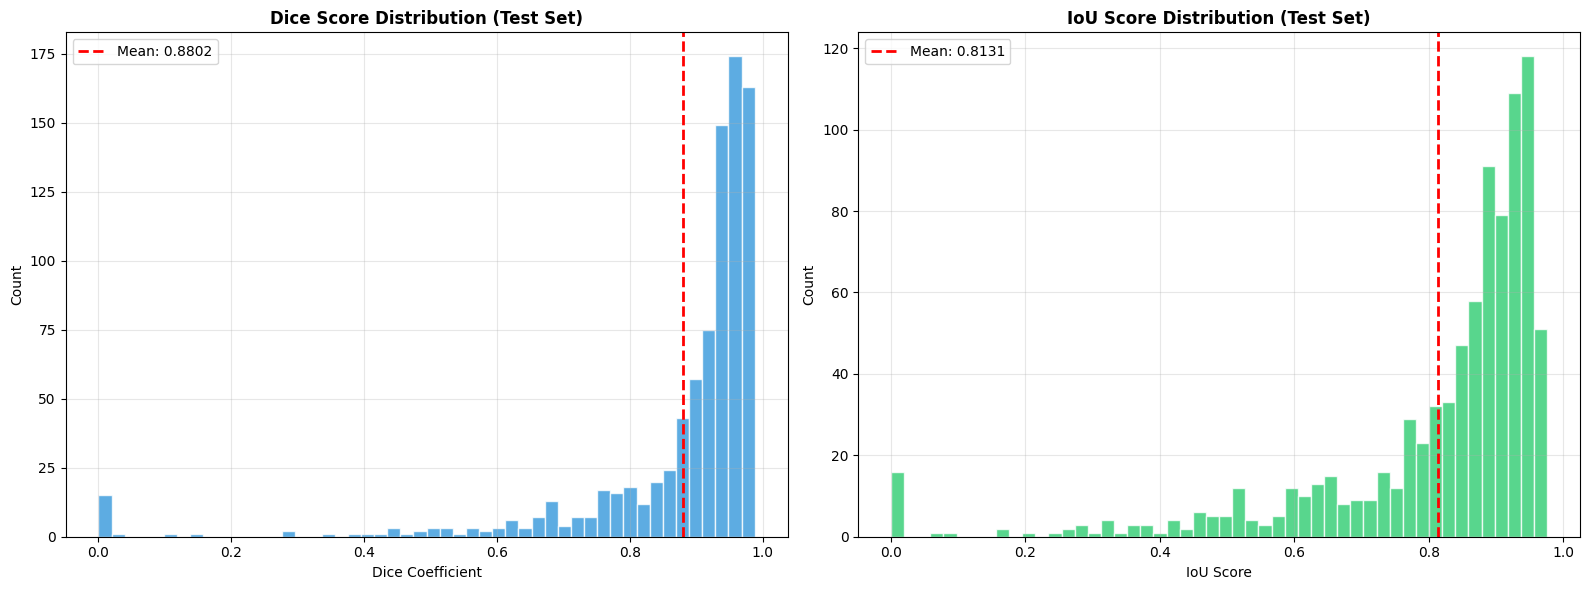

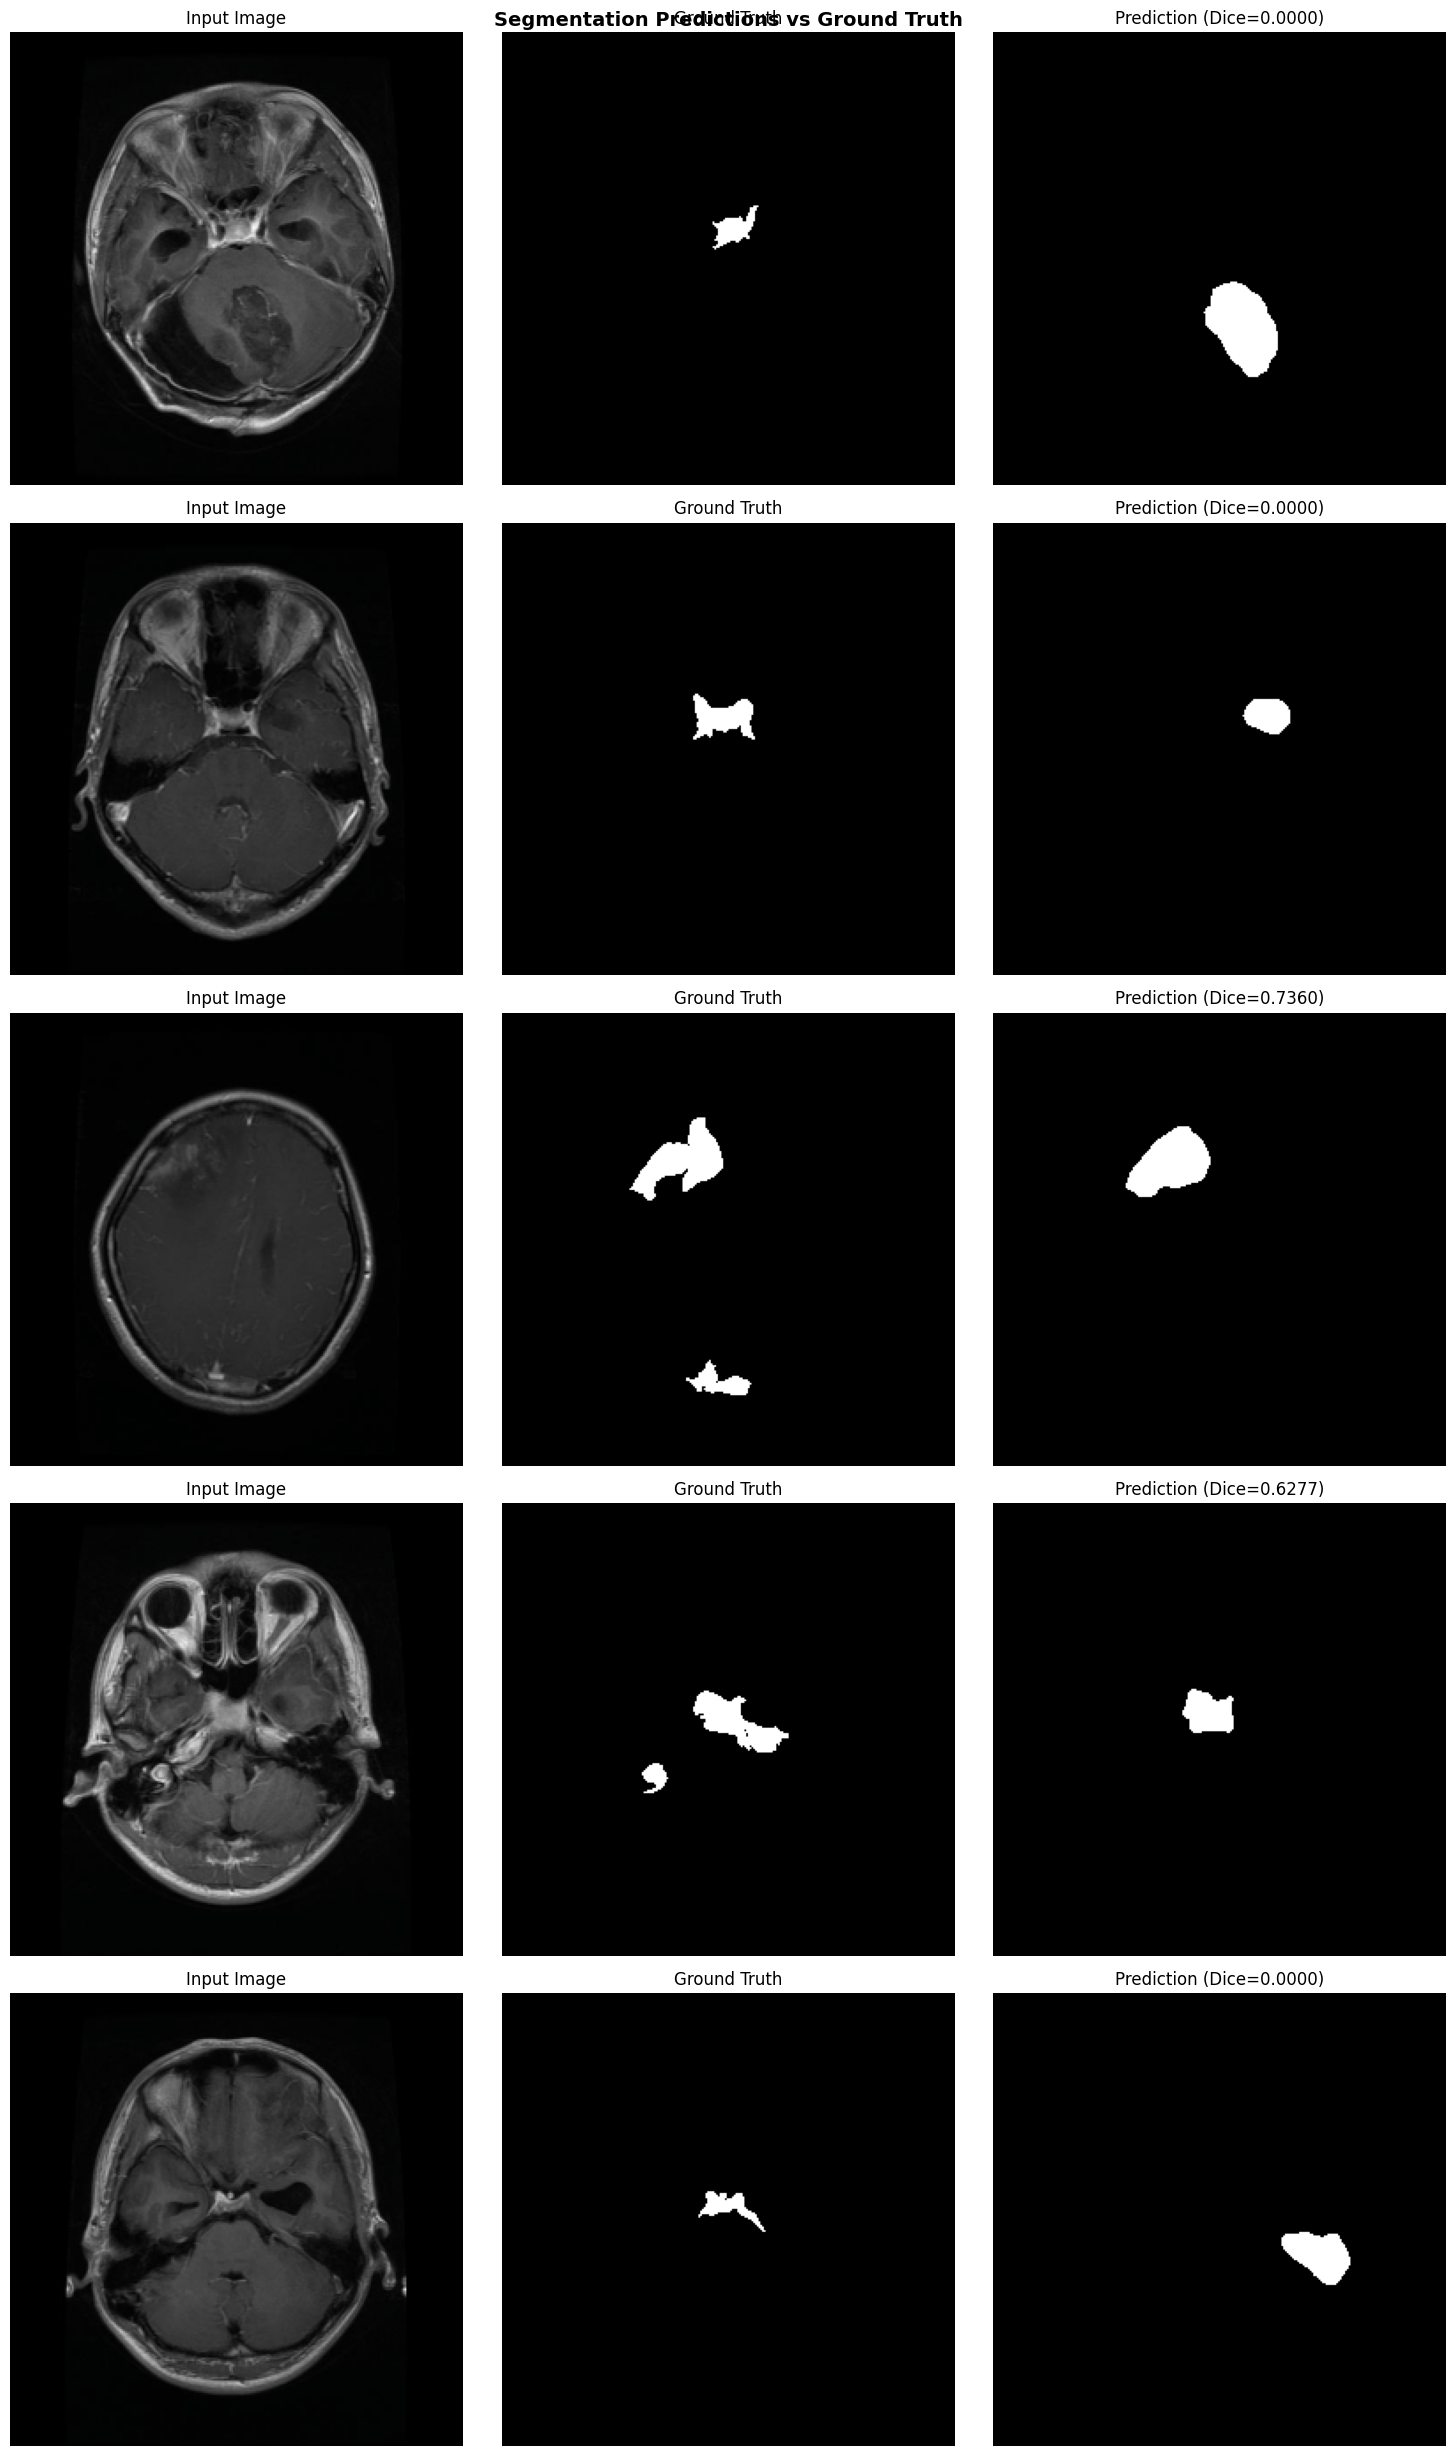

💾 Segmentation visualizations saved


In [28]:
# Dice distribution histogram
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].hist(seg_records['dice'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(np.mean(seg_records['dice']), color='red', ls='--', lw=2, label=f"Mean: {np.mean(seg_records['dice']):.4f}")
axes[0].set_xlabel('Dice Coefficient'); axes[0].set_ylabel('Count')
axes[0].set_title('Dice Score Distribution (Test Set)', fontweight='bold'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(seg_records['iou'], bins=50, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].axvline(np.mean(seg_records['iou']), color='red', ls='--', lw=2, label=f"Mean: {np.mean(seg_records['iou']):.4f}")
axes[1].set_xlabel('IoU Score'); axes[1].set_ylabel('Count')
axes[1].set_title('IoU Score Distribution (Test Set)', fontweight='bold'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_SAVE, 'seg_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

# Sample predictions
fig, axes = plt.subplots(5, 3, figsize=(15, 25))
mean_vals, std_vals = np.array([0.485,0.456,0.406]), np.array([0.229,0.224,0.225])
val_iter = iter(val_loader)
images_batch, masks_batch = next(val_iter)
with torch.no_grad():
    with torch.amp.autocast('cuda'):
        logits = seg_model(images_batch.to(device))
        if isinstance(logits, tuple): logits = logits[0]
preds_batch = (torch.sigmoid(logits).cpu() > seg_thresh).float()
for i in range(min(5, images_batch.size(0))):
    img = np.clip(images_batch[i].permute(1,2,0).numpy()*std_vals+mean_vals, 0, 1)
    gt_mask = masks_batch[i, 0].numpy()
    pred_mask = preds_batch[i, 0].numpy()
    d = dice_coefficient(preds_batch[i], masks_batch[i]).item()
    axes[i,0].imshow(img); axes[i,0].set_title('Input Image'); axes[i,0].axis('off')
    axes[i,1].imshow(gt_mask, cmap='gray'); axes[i,1].set_title('Ground Truth'); axes[i,1].axis('off')
    axes[i,2].imshow(pred_mask, cmap='gray'); axes[i,2].set_title(f'Prediction (Dice={d:.4f})'); axes[i,2].axis('off')
plt.suptitle('Segmentation Predictions vs Ground Truth', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_SAVE, 'seg_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Segmentation visualizations saved')

## 📊 Step 18 — Comprehensive Classification Metrics
All models across Stage 4 and Stage 5 with full metrics suite.

In [29]:
def cls_metrics(y_true, y_pred, y_prob, name):
    m = {}
    m['Accuracy'] = accuracy_score(y_true, y_pred)
    m['Balanced Accuracy'] = balanced_accuracy_score(y_true, y_pred)
    m['Macro F1'] = f1_score(y_true, y_pred, average='macro')
    m['Weighted F1'] = f1_score(y_true, y_pred, average='weighted')
    m['Macro Precision'] = precision_score(y_true, y_pred, average='macro')
    m['Macro Recall'] = recall_score(y_true, y_pred, average='macro')
    m['Cohen Kappa'] = cohen_kappa_score(y_true, y_pred)
    m['MCC'] = matthews_corrcoef(y_true, y_pred)
    if y_prob is not None:
        try:
            y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
            m['ROC-AUC (OVR)'] = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')
        except: m['ROC-AUC (OVR)'] = float('nan')
    print(f"\n{'='*50}")
    print(f"  📊 {name}")
    print(f"{'='*50}")
    print(f"  {'Metric':<22} {'Value':>8}")
    print(f"  {'-'*32}")
    for k, v in m.items(): print(f"  {k:<22} {v:>8.4f}")
    pc_p = precision_score(y_true, y_pred, average=None)
    pc_r = recall_score(y_true, y_pred, average=None)
    pc_f = f1_score(y_true, y_pred, average=None)
    print(f"\n  Per-Class:")
    print(f"  {'Class':<14} {'Prec':>7} {'Rec':>7} {'F1':>7}")
    for i, cn in enumerate(CLASS_NAMES):
        print(f"  {cn:<14} {pc_p[i]:>7.4f} {pc_r[i]:>7.4f} {pc_f[i]:>7.4f}")
    return m

# ── Stage 4 Metrics ──
print('\n' + '='*70)
print('  STAGE 4 — CLASSIFICATION METRICS')
print('='*70)
all_cls_metrics = {}
all_cls_metrics['MLP'] = cls_metrics(y_test, mlp_preds, mlp_probs, 'Deep MLP')
all_cls_metrics['SVM'] = cls_metrics(y_test, svm_preds, svm_probs, 'SVM (GridSearch)')
all_cls_metrics['RF'] = cls_metrics(y_test, rf_preds, rf_probs, 'Random Forest')
all_cls_metrics['LR'] = cls_metrics(y_test, lr_preds, lr_probs, 'Logistic Regression')
all_cls_metrics[f'S4 Ensemble ({s4_best_name})'] = cls_metrics(y_test, s4_best_preds, s4_best_probs, f'Stage 4 Ensemble ({s4_best_name})')

# ── Stage 5 Metrics ──
print('\n' + '='*70)
print('  STAGE 5 — CLASSIFICATION METRICS')
print('='*70)
all_cls_metrics[f'S5 Ensemble ({s5_ens_name}+TTA)'] = cls_metrics(s5_y_true, s5_final_preds, s5_final_probs, f'Stage 5 Ensemble ({s5_ens_name}+TTA)')

# ── Summary Table ──
print('\n\n' + '='*90)
print('  COMPREHENSIVE COMPARISON TABLE')
print('='*90)
sum_keys = ['Accuracy','Balanced Accuracy','Macro F1','Weighted F1','Cohen Kappa','MCC','ROC-AUC (OVR)']
header = f"  {'Metric':<22}" + ''.join(f'{n:>16}' for n in all_cls_metrics.keys())
print(header); print(f"  {'-'*(22+16*len(all_cls_metrics))}")
for key in sum_keys:
    row = f"  {key:<22}"
    for name, metrics in all_cls_metrics.items():
        val = metrics.get(key, float('nan'))
        row += f'{val:>16.4f}'
    print(row)

# Save classification metrics
cls_metrics_save = {name: {k: float(v) for k, v in metrics.items()} for name, metrics in all_cls_metrics.items()}
with open(os.path.join(EVAL_SAVE, 'classification_metrics.json'), 'w') as f:
    json.dump(cls_metrics_save, f, indent=2)
print(f'\n💾 Classification metrics saved to {EVAL_SAVE}/classification_metrics.json')


  STAGE 4 — CLASSIFICATION METRICS

  📊 Deep MLP
  Metric                    Value
  --------------------------------
  Accuracy                 0.9350
  Balanced Accuracy        0.9268
  Macro F1                 0.9255
  Weighted F1              0.9348
  Macro Precision          0.9251
  Macro Recall             0.9268
  Cohen Kappa              0.9112
  MCC                      0.9115
  ROC-AUC (OVR)            0.9867

  Per-Class:
  Class             Prec     Rec      F1
  glioma          0.9447  0.8740  0.9080
  meningioma      0.9585  0.9804  0.9693
  pituitary       0.9412  0.9600  0.9505
  no_tumor        0.8562  0.8929  0.8741

  📊 SVM (GridSearch)
  Metric                    Value
  --------------------------------
  Accuracy                 0.9230
  Balanced Accuracy        0.9216
  Macro F1                 0.9168
  Weighted F1              0.9230
  Macro Precision          0.9135
  Macro Recall             0.9216
  Cohen Kappa              0.8951
  MCC                      

## 🔥 Step 19 — Confusion Matrices

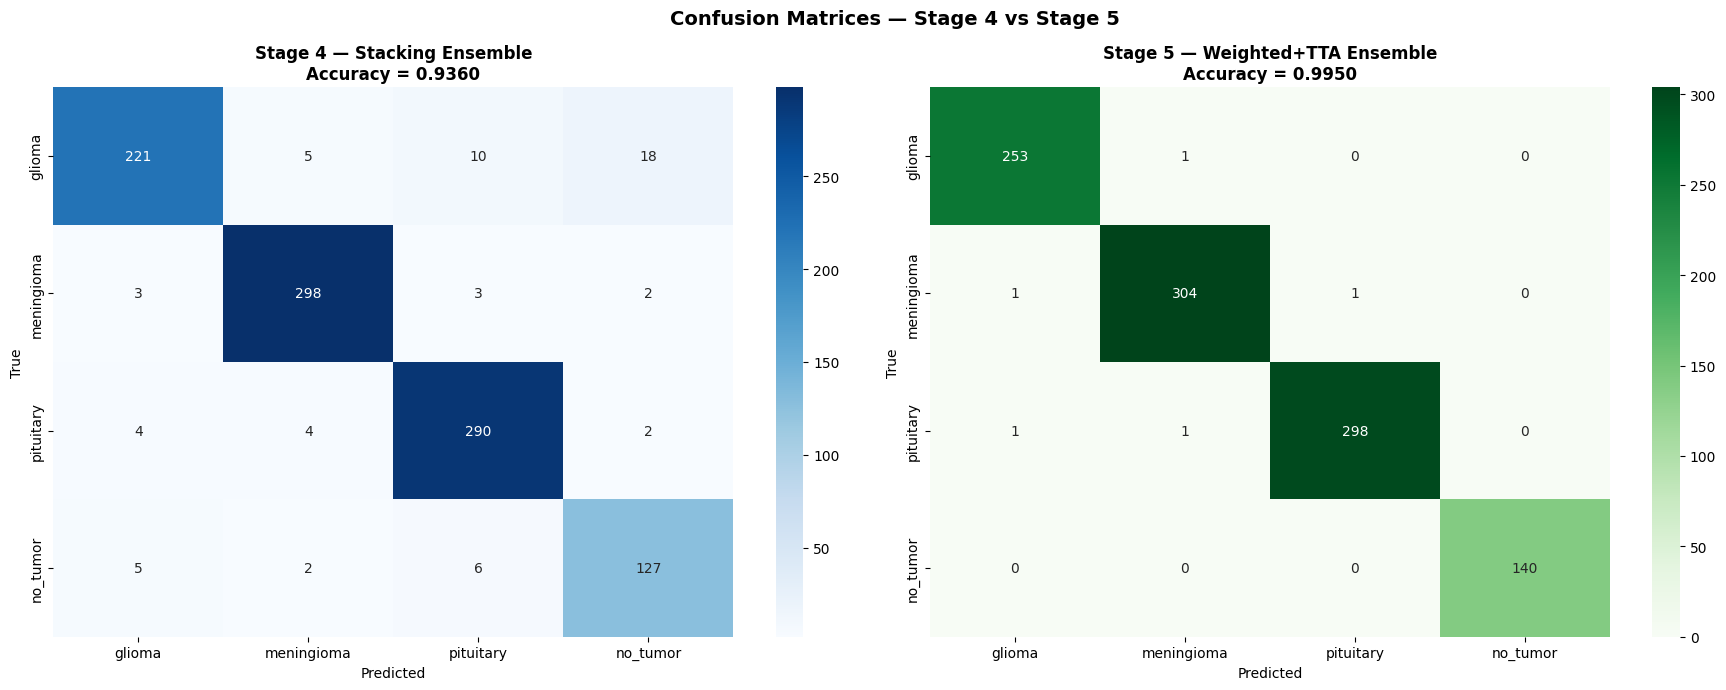

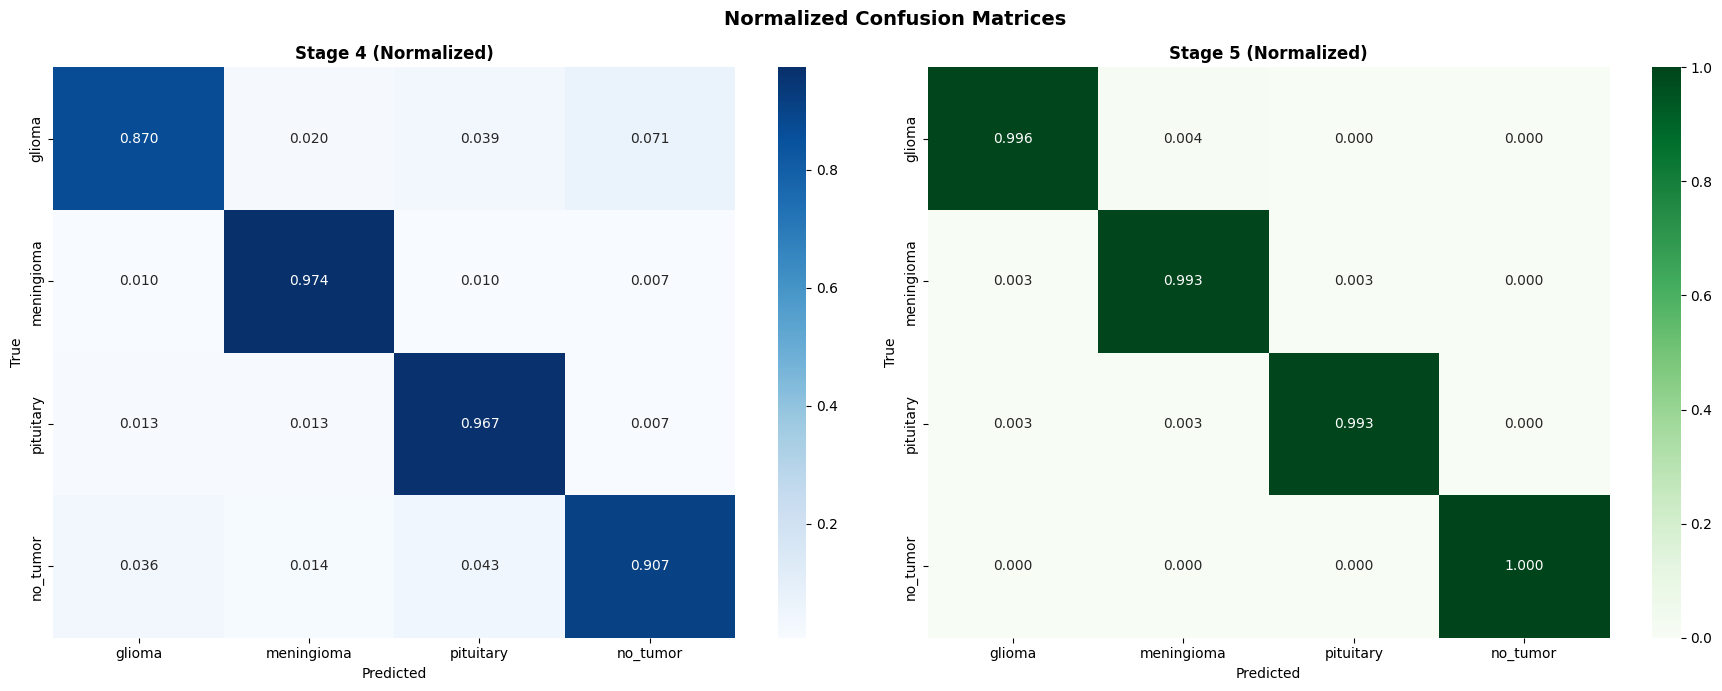

💾 Confusion matrices saved


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Stage 4 best
cm4 = confusion_matrix(y_test, s4_best_preds)
sns.heatmap(cm4, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title(f'Stage 4 — {s4_best_name} Ensemble\nAccuracy = {s4_best_acc:.4f}', fontweight='bold', fontsize=12)
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

# Stage 5 best
cm5 = confusion_matrix(s5_y_true, s5_final_preds)
sns.heatmap(cm5, annot=True, fmt='d', cmap='Greens', ax=axes[1], xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[1].set_title(f'Stage 5 — {s5_ens_name}+TTA Ensemble\nAccuracy = {s5_best_acc:.4f}', fontweight='bold', fontsize=12)
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Stage 4 vs Stage 5', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_SAVE, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

# Normalized confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
cm4n = cm4.astype('float')/cm4.sum(axis=1, keepdims=True)
cm5n = cm5.astype('float')/cm5.sum(axis=1, keepdims=True)
sns.heatmap(cm4n, annot=True, fmt='.3f', cmap='Blues', ax=axes[0], xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title(f'Stage 4 (Normalized)', fontweight='bold'); axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm5n, annot=True, fmt='.3f', cmap='Greens', ax=axes[1], xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[1].set_title(f'Stage 5 (Normalized)', fontweight='bold'); axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')
plt.suptitle('Normalized Confusion Matrices', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_SAVE, 'confusion_matrices_normalized.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Confusion matrices saved')

## 📈 Step 20 — ROC Curves

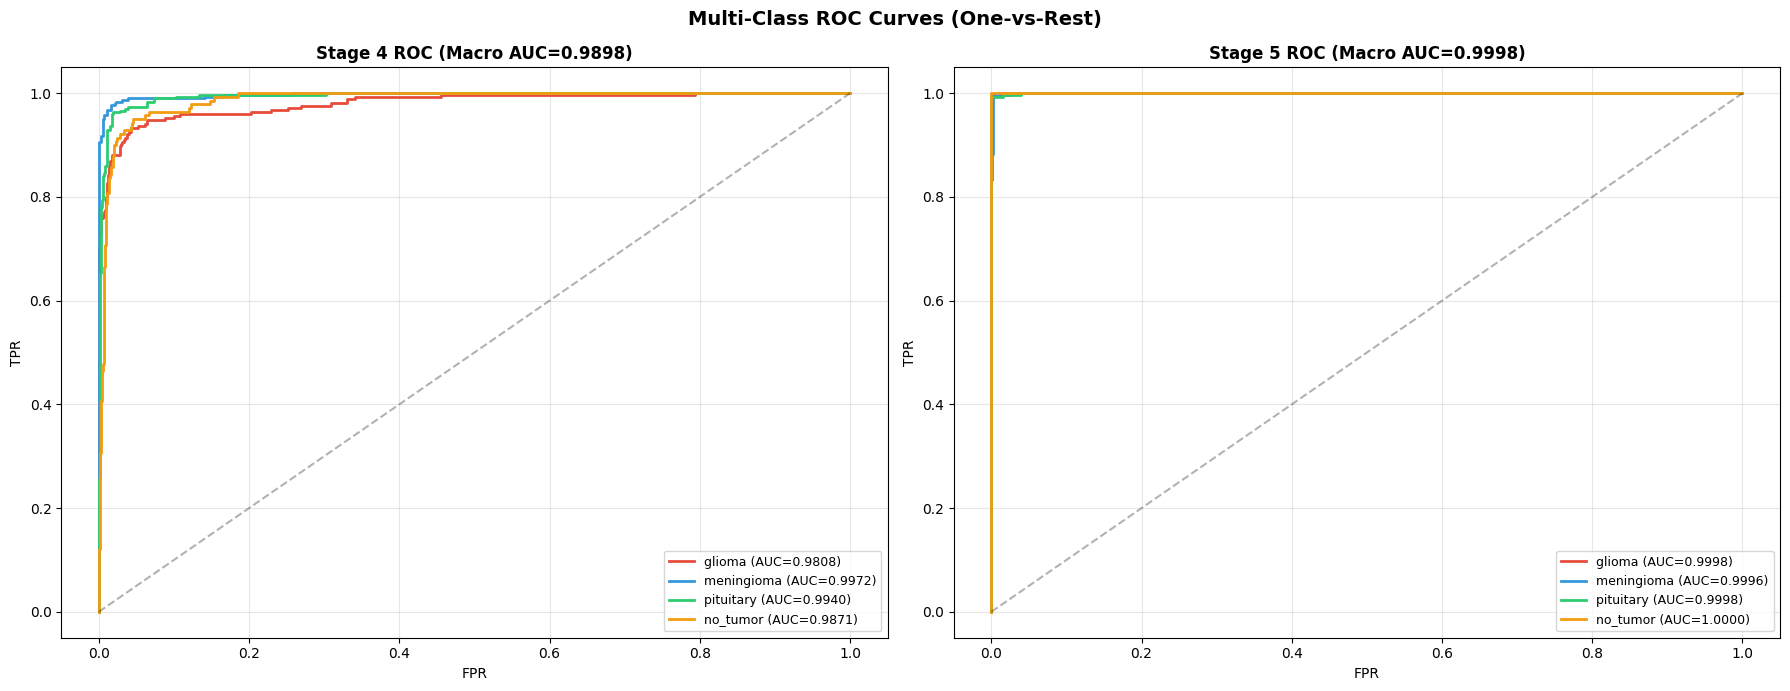

  Stage 4 Macro AUC: 0.9898
  Stage 5 Macro AUC: 0.9998
💾 ROC curves saved


In [31]:
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Stage 4 ROC
y_test_bin = label_binarize(y_test, classes=list(range(NUM_CLASSES)))
for i, (cn, col) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], s4_best_probs[:, i])
    roc_auc_val = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=col, lw=2, label=f'{cn} (AUC={roc_auc_val:.4f})')
axes[0].plot([0,1],[0,1],'k--',alpha=0.3)
macro_auc4 = roc_auc_score(y_test_bin, s4_best_probs, multi_class='ovr', average='macro')
axes[0].set_title(f'Stage 4 ROC (Macro AUC={macro_auc4:.4f})', fontweight='bold')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Stage 5 ROC
s5_y_bin = label_binarize(s5_y_true, classes=list(range(NUM_CLASSES)))
for i, (cn, col) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(s5_y_bin[:, i], s5_final_probs[:, i])
    roc_auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=col, lw=2, label=f'{cn} (AUC={roc_auc_val:.4f})')
axes[1].plot([0,1],[0,1],'k--',alpha=0.3)
macro_auc5 = roc_auc_score(s5_y_bin, s5_final_probs, multi_class='ovr', average='macro')
axes[1].set_title(f'Stage 5 ROC (Macro AUC={macro_auc5:.4f})', fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Multi-Class ROC Curves (One-vs-Rest)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_SAVE, 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'  Stage 4 Macro AUC: {macro_auc4:.4f}')
print(f'  Stage 5 Macro AUC: {macro_auc5:.4f}')
print('💾 ROC curves saved')

## 🏆 Step 21 — Cross-Stage Comparison & Final Summary


  🏆 FINAL CROSS-STAGE COMPARISON


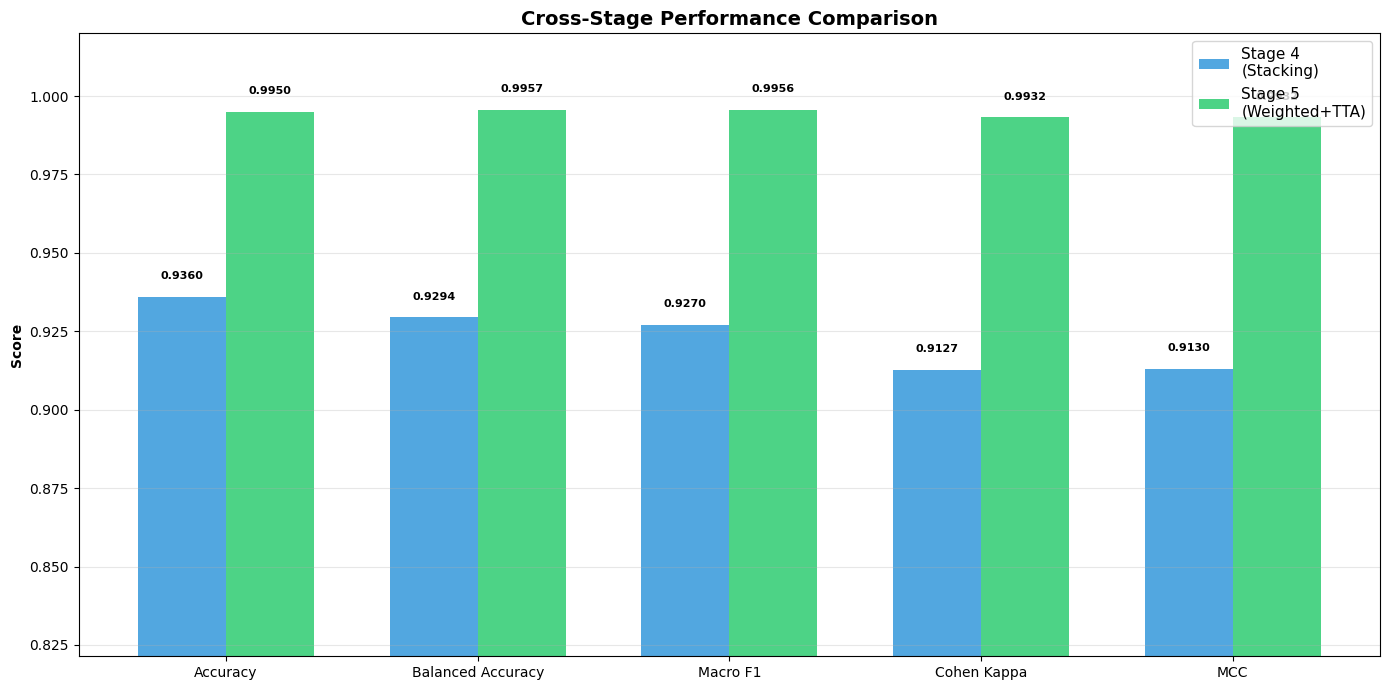


  Metric                      Stage 4      Stage 5    Improvement
  --------------------------------------------------------------
  Accuracy                     0.9360       0.9950        +0.0590
  Balanced Accuracy            0.9294       0.9957        +0.0663
  Macro F1                     0.9270       0.9956        +0.0686
  Cohen Kappa                  0.9127       0.9932        +0.0805
  MCC                          0.9130       0.9932        +0.0801

  Stage 4 Macro AUC: 0.9898
  Stage 5 Macro AUC: 0.9998

  ✅ ALL METRICS AND EVALUATIONS COMPLETE!
  📁 All artifacts saved to: /content/drive/MyDrive/BRICS_FEATURES_IN-drive

💾 Complete summary saved to /content/drive/MyDrive/BRICS_FEATURES_IN-drive/evaluation/complete_summary.json


In [32]:
print('\n' + '='*70)
print('  🏆 FINAL CROSS-STAGE COMPARISON')
print('='*70)

# Bar chart
fig, ax = plt.subplots(figsize=(14, 7))
stages = [f'Stage 4\n({s4_best_name})', f'Stage 5\n({s5_ens_name}+TTA)']
metrics_to_plot = ['Accuracy', 'Balanced Accuracy', 'Macro F1', 'Cohen Kappa', 'MCC']
s4_vals = [all_cls_metrics[f'S4 Ensemble ({s4_best_name})'].get(m, 0) for m in metrics_to_plot]
s5_vals = [all_cls_metrics[f'S5 Ensemble ({s5_ens_name}+TTA)'].get(m, 0) for m in metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.35
bars1 = ax.bar(x - width/2, s4_vals, width, label=stages[0], color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, s5_vals, width, label=stages[1], color='#2ecc71', alpha=0.85)

for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Cross-Stage Performance Comparison', fontweight='bold', fontsize=14)
ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot, fontsize=10)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(min(min(s4_vals), min(s5_vals))*0.9, 1.02)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_SAVE, 'cross_stage_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print final summary
print(f"\n  {'Metric':<22} {'Stage 4':>12} {'Stage 5':>12} {'Improvement':>14}")
print(f"  {'-'*62}")
for m in metrics_to_plot:
    v4 = all_cls_metrics[f'S4 Ensemble ({s4_best_name})'].get(m, 0)
    v5 = all_cls_metrics[f'S5 Ensemble ({s5_ens_name}+TTA)'].get(m, 0)
    imp = v5 - v4
    print(f"  {m:<22} {v4:>12.4f} {v5:>12.4f} {f'+{imp:.4f}' if imp>=0 else f'{imp:.4f}':>14}")

print(f'\n  Stage 4 Macro AUC: {macro_auc4:.4f}')
print(f'  Stage 5 Macro AUC: {macro_auc5:.4f}')
print(f'\n{"="*70}')
print(f'  ✅ ALL METRICS AND EVALUATIONS COMPLETE!')
print(f'  📁 All artifacts saved to: {MASTER_SAVE}')
print(f'{"="*70}')

# Save complete summary
summary = {
    'segmentation': seg_metrics_dict,
    'classification_stage4': {k: {mk: float(mv) for mk, mv in v.items()} for k, v in all_cls_metrics.items() if 'S4' in k or k in ['MLP','SVM','RF','LR','Random Forest','Logistic Regression']},
    'classification_stage5': {k: {mk: float(mv) for mk, mv in v.items()} for k, v in all_cls_metrics.items() if 'S5' in k},
    'macro_auc_stage4': float(macro_auc4),
    'macro_auc_stage5': float(macro_auc5),
    'save_directory': MASTER_SAVE,
}
with open(os.path.join(EVAL_SAVE, 'complete_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)
print(f'\n💾 Complete summary saved to {EVAL_SAVE}/complete_summary.json')


  🏆 FINAL CROSS-STAGE COMPARISON


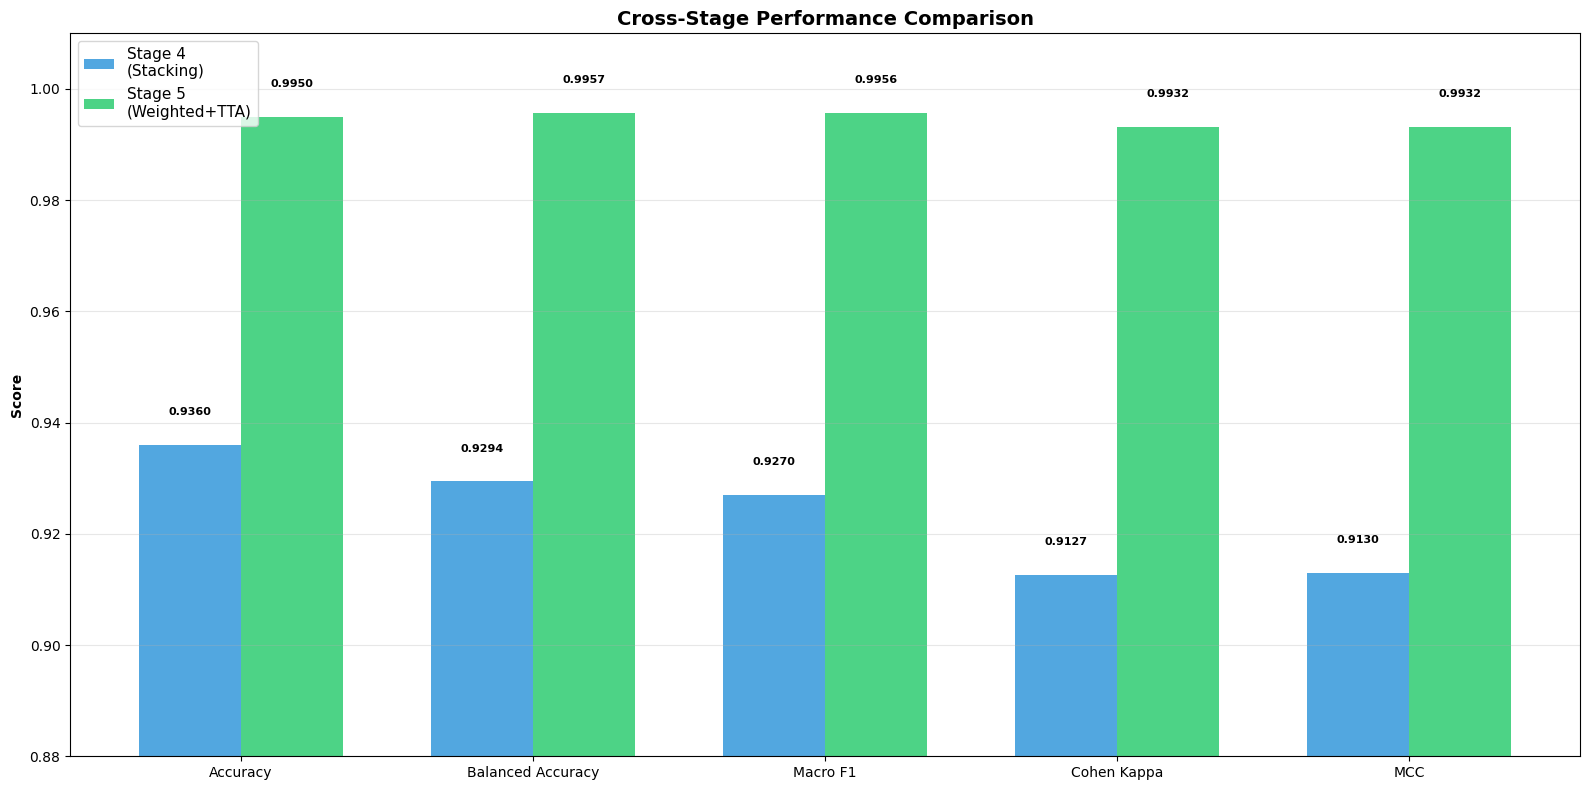


  Metric                      Stage 4      Stage 5    Improvement
  --------------------------------------------------------------
  Accuracy                     0.9360       0.9950        +0.0590
  Balanced Accuracy            0.9294       0.9957        +0.0663
  Macro F1                     0.9270       0.9956        +0.0686
  Cohen Kappa                  0.9127       0.9932        +0.0805
  MCC                          0.9130       0.9932        +0.0801

  Stage 4 Macro AUC: 0.9898
  Stage 5 Macro AUC: 0.9998

  ✅ ALL METRICS AND EVALUATIONS COMPLETE!
  📁 All artifacts saved to: /content/drive/MyDrive/BRICS_FEATURES_IN-drive

💾 Complete summary saved to /content/drive/MyDrive/BRICS_FEATURES_IN-drive/evaluation/complete_summary.json


In [34]:
print('\n' + '='*70)
print('  🏆 FINAL CROSS-STAGE COMPARISON')
print('='*70)

# Bar chart
fig, ax = plt.subplots(figsize=(16, 8))
stages = [f'Stage 4\n({s4_best_name})', f'Stage 5\n({s5_ens_name}+TTA)']
metrics_to_plot = ['Accuracy', 'Balanced Accuracy', 'Macro F1', 'Cohen Kappa', 'MCC']
s4_vals = [all_cls_metrics[f'S4 Ensemble ({s4_best_name})'].get(m, 0) for m in metrics_to_plot]
s5_vals = [all_cls_metrics[f'S5 Ensemble ({s5_ens_name}+TTA)'].get(m, 0) for m in metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.35
bars1 = ax.bar(x - width/2, s4_vals, width, label=stages[0], color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, s5_vals, width, label=stages[1], color='#2ecc71', alpha=0.85)

for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Cross-Stage Performance Comparison', fontweight='bold', fontsize=14)
ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot, fontsize=10)
ax.legend(fontsize=11, loc='upper left'); ax.grid(True, alpha=0.3, axis='y')

ax.set_ylim(0.88, 1.01)

plt.tight_layout()
plt.savefig(os.path.join(EVAL_SAVE, 'cross_stage_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print final summary
print(f"\n  {'Metric':<22} {'Stage 4':>12} {'Stage 5':>12} {'Improvement':>14}")
print(f"  {'-'*62}")
for m in metrics_to_plot:
    v4 = all_cls_metrics[f'S4 Ensemble ({s4_best_name})'].get(m, 0)
    v5 = all_cls_metrics[f'S5 Ensemble ({s5_ens_name}+TTA)'].get(m, 0)
    imp = v5 - v4
    print(f"  {m:<22} {v4:>12.4f} {v5:>12.4f} {f'+{imp:.4f}' if imp>=0 else f'{imp:.4f}':>14}")

print(f'\n  Stage 4 Macro AUC: {macro_auc4:.4f}')
print(f'  Stage 5 Macro AUC: {macro_auc5:.4f}')
print(f'\n{"="*70}')
print(f'  ✅ ALL METRICS AND EVALUATIONS COMPLETE!')
print(f'  📁 All artifacts saved to: {MASTER_SAVE}')
print(f'{"="*70}')

# Save complete summary
summary = {
    'segmentation': seg_metrics_dict,
    'classification_stage4': {k: {mk: float(mv) for mk, mv in v.items()} for k, v in all_cls_metrics.items() if 'S4' in k or k in ['MLP','SVM','RF','LR','Random Forest','Logistic Regression']},
    'classification_stage5': {k: {mk: float(mv) for mk, mv in v.items()} for k, v in all_cls_metrics.items() if 'S5' in k},
    'macro_auc_stage4': float(macro_auc4),
    'macro_auc_stage5': float(macro_auc5),
    'save_directory': MASTER_SAVE,
}
with open(os.path.join(EVAL_SAVE, 'complete_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)
print(f'\n💾 Complete summary saved to {EVAL_SAVE}/complete_summary.json')